#  EDA  and Price Predicting ML model for Mobile Phones

**System Role:** objective is to build a predictive model that can accurately estimate the price of a mobile phone based on its features.  
**Dataset:** `processed.csv`  
**Prepared by:**  GOVIND MISHRA

#  phase 1: Preprocessing, cleaning , handling missing values 

In [48]:
# Libraries Used: pandas, numpy, scipy, matplotlib, seaborn, sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
# Load data and strip indexing artifacts
df = pd.read_csv('processed.csv')
df
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df

# --- Plotting Helper Functions to Shorten Code ---

def plot_numerical_univariate(df, col, color, title, xlabel, ylabel, suptitle, bins=20, decimals=2, boxplot_title=None):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    data = df[col].dropna()
    mean_val = data.mean()
    median_val = data.median()
    
    # Histogram + KDE
    sns.histplot(data, kde=True, color=color, bins=bins, ax=axes[0], alpha=0.6)
    axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:,.{decimals}f}')
    axes[0].axvline(median_val, color='blue', linestyle='-.', linewidth=1.5, label=f'Median: {median_val:,.{decimals}f}')
    axes[0].set_title(title, fontsize=12, weight='bold')
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel('Density / Count')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.3)

    # Boxplot
    sns.boxplot(y=data, color=color, ax=axes[1], flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
    axes[1].set_title(boxplot_title if boxplot_title else title.replace('Distribution Histogram & KDE', 'Outliers Boxplot').replace('Distribution & KDE', 'Outliers Boxplot'), fontsize=12, weight='bold')
    axes[1].set_ylabel(ylabel)
    axes[1].grid(True, linestyle='--', alpha=0.3)

    plt.suptitle(suptitle, fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

def plot_categorical_count(df, col, title, ylabel, xlabel='Count', palette='viridis', figsize=(10, 6), text_offset=2, top_n=None):
    plt.figure(figsize=figsize)
    counts = df[col].value_counts()
    if top_n:
        counts = counts.head(top_n)
        df_plot = df[df[col].isin(counts.index)]
    else:
        df_plot = df
        
    sns.countplot(
        data=df_plot,
        y=col,
        order=counts.index,
        palette=palette,
        hue=col,
        legend=False
    )
    total = len(df)
    for i, count in enumerate(counts):
        pct = f"{count/total*100:.1f}%"
        plt.text(count + text_offset, i, f"{count} ({pct})", va='center', fontsize=10, weight='bold')

    plt.title(title, fontsize=14, weight='bold')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

def plot_bivariate_scatter(df, x_col, y_col, color, title, xlabel, ylabel, figsize=(10, 6)):
    from scipy import stats
    r_val, p_val = stats.pearsonr(df[x_col], df[y_col])
    slope, intercept, r_value, p_value, std_err = stats.linregress(df[x_col], df[y_col])

    plt.figure(figsize=figsize)
    sns.regplot(data=df, x=x_col, y=y_col, color=color, scatter_kws={'alpha': 0.4}, line_kws={'color': 'red', 'linewidth': 2})

    stats_text = (f"Pearson r = {r_val:.2f}\n"
                  f"p-value = {p_val:.2e}\n"
                  f"y = {slope:.2f}x + {intercept:.2f}\n"
                  f"R² = {r_value**2:.2f}")
    plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes,
                   fontsize=10, bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8),
                   verticalalignment='top', horizontalalignment='left')

    plt.title(title, fontsize=14, weight='bold')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

def plot_price_by_categorical(df, col, palette, title_plural, xlabel, suptitle, figsize=(18, 7), top_n=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    if top_n:
        top_cats = df[col].value_counts().head(top_n).index
        df_sub = df[df[col].isin(top_cats)]
    else:
        df_sub = df
        
    sns.boxplot(data=df_sub, x=col, y='Price', palette=palette, ax=axes[0], hue=col, legend=False)
    axes[0].set_title(f'Price Distribution across {title_plural}', fontsize=12, weight='bold')
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel('Price (INR)')
    axes[0].grid(True, linestyle='--', alpha=0.3)

    sns.barplot(data=df_sub, x=col, y='Price', palette=palette, ax=axes[1], errorbar='ci', hue=col, legend=False)
    axes[1].set_title(f'Mean Price across {title_plural}', fontsize=12, weight='bold')
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel('Mean Price (INR)')
    axes[1].grid(True, linestyle='--', alpha=0.3)

    for p in axes[1].patches:
        height = p.get_height()
        if height > 0:
            axes[1].annotate(f'{height:,.0f} INR',
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='bottom',
                             xytext=(0, 5), textcoords='offset points',
                             fontsize=10, weight='bold')

    plt.suptitle(suptitle, fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()



In [49]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    str    
 1   Colour         541 non-null    str    
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    str    
 6   Front Camera   541 non-null    str    
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    str    
 10  Prize          541 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 76.5 KB


Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

In [50]:
df.shape

(541, 11)

In [51]:

df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
536    False
537    False
538    False
539    False
540    False
Length: 541, dtype: bool

In [52]:
df_copy = df.copy()
df_copy.head(2)

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"


In [53]:
df_copy['Model'].unique()

<ArrowStringArray>
[      'Infinix SMART 7',          'MOTOROLA G32',              'POCO C50',
       'Infinix HOT 30i',              'REDMI 10',    'SAMSUNG Galaxy F13',
    'SAMSUNG Galaxy F04',              'POCO C51',          'MOTOROLA e13',
           'vivo T2x 5G',
 ...
    'SAMSUNG Galaxy A04',         'OPPO F21s Pro',       'APPLE iPhone 12',
    'SAMSUNG Galaxy A13',        'Nokia G11 Plus',   'SAMSUNG Galaxy A04e',
 'SAMSUNG Galaxy S23 5G',              'LAVA Z21',        'Tecno Spark 8T',
              'OPPO A77']
Length: 187, dtype: str

In [54]:
df_copy['Model_name'] = df_copy['Model'].str.split(' ').str[0]
df_copy['Model_name'].unique()

array(['Infinix', 'MOTOROLA', 'POCO', 'REDMI', 'SAMSUNG', 'vivo',
       'realme', 'Micromax', 'micromax', 'Google', 'micromax1', 'OPPO',
       'redmi', 'Tecno', 'nothing', 'I', 'itel', 'OnePlus', 'IQOO',
       'Redmi', 'Nokia', 'APPLE', 'LAVA'], dtype=object)

In [55]:
#  replacing 'I' with 'IKALL' and standardizing brand names to unify casing and spelling
df_copy['Model_name'] = df_copy['Model_name'].replace('I', 'IKALL')

# Standardize case and spelling of brand names to combine duplicates (e.g. REDMI & redmi, micromax & Micromax)
brand_standardization = {
    'realme': 'Realme',
    'REDMI': 'Redmi',
    'redmi': 'Redmi',
    'Infinix': 'Infinix',
    'vivo': 'Vivo',
    'POCO': 'Poco',
    'SAMSUNG': 'Samsung',
    'MOTOROLA': 'Motorola',
    'Tecno': 'Tecno',
    'OPPO': 'Oppo',
    'micromax': 'Micromax',
    'Micromax': 'Micromax',
    'Google': 'Google',
    'OnePlus': 'OnePlus',
    'APPLE': 'Apple'
}
df_copy['Model_name'] = df_copy['Model_name'].replace(brand_standardization)
df_copy['Model_name'].unique()

array(['Infinix', 'Motorola', 'Poco', 'Redmi', 'Samsung', 'Vivo',
       'Realme', 'Micromax', 'Google', 'micromax1', 'Oppo', 'Tecno',
       'nothing', 'IKALL', 'itel', 'OnePlus', 'IQOO', 'Nokia', 'Apple',
       'LAVA'], dtype=object)

In [56]:
df_copy = df_copy.rename(columns={'Prize': 'Price'})
df_copy['Price'] = df_copy['Price'].astype(str).str.replace(',', '')
df_copy['Price'] = df_copy['Price'].astype(int)
df_copy.head(20)

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Price,Model_name
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299,Infinix
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299,Infinix
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999,Motorola
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649,Poco
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999,Infinix
5,Infinix HOT 30i,Glacier Blue,128,8,5000,50MP,5MP,1,16.76,G37,8999,Infinix
6,Infinix HOT 30i,Mirror Black,128,8,5000,50MP,5MP,1,16.76,G37,8999,Infinix
7,Infinix HOT 30i,Diamond White,128,8,5000,50MP,5MP,1,16.76,G37,8999,Infinix
8,Infinix HOT 30i,Diamond White,64,4,5000,50MP,5MP,1,16.76,G37,7999,Infinix
9,Infinix HOT 30i,Mirror Black,64,4,5000,50MP,5MP,1,16.76,G37,7999,Infinix


In [57]:
# Processor & Colour feature extraction and column cleanup
import re


def extract_processor_family(processor_value):
    processor = str(processor_value).lower().strip()
    if not processor or processor == 'nan':
        return 'Unknown'
    if 'apple' in processor or 'bionic' in processor:
        return 'Apple'
    if 'snapdragon' in processor or 'qualcomm' in processor:
        return 'Snapdragon'
    if 'mediatek' in processor or 'helio' in processor or 'dimensity' in processor or 'mtk' in processor or 'mt' in processor:
        return 'MediaTek'
    if 'unisoc' in processor or 'spreadtrum' in processor:
        return 'Unisoc'
    if 'exynos' in processor:
        return 'Exynos'
    if 'tensor' in processor:
        return 'Google Tensor'
    if 'octa' in processor:
        return 'Octa-Core'
    if 'quad' in processor:
        return 'Quad-Core'
    return 'Other'


def extract_base_color(color_name):
    c = str(color_name).lower().strip()
    if any(k in c for k in ['black', 'onyx', 'obsidian', 'dark matter', 'night sea', 'midnight', 'graphite', 'shadow', 'charcoal', 'punk', 'stealth', 'night']):
        return 'Black'
    elif any(k in c for k in ['blue', 'azure', 'cyan', 'aqua', 'wave', 'sea', 'ocean', 'sky', 'indigo', 'ice', 'dawn', 'frost', 'blaze', 'turquoise']):
        return 'Blue'
    elif any(k in c for k in ['green', 'mint', 'emerald', 'forest', 'apple', 'menthe', 'lime', 'rainforest', 'lemongrass', 'olive', 'vert']):
        return 'Green'
    elif any(k in c for k in ['white', 'snow', 'pearl', 'cream', 'lily', 'starlight', 'chalk', 'halo', 'pearly']):
        return 'White'
    elif any(k in c for k in ['gray', 'grey', 'slate', 'silver', 'mithril', 'titanium']):
        return 'Gray/Silver'
    elif any(k in c for k in ['gold', 'yellow', 'marigold', 'copper', 'sunlight', 'sunshower', 'bronze', 'glow', 'hyperspace', 'metallica']):
        return 'Gold/Yellow'
    elif any(k in c for k in ['purple', 'lavender', 'violet', 'iris', 'jade', 'galaxy']):
        return 'Purple'
    elif any(k in c for k in ['orange', 'peach', 'shimmer', 'apricot']):
        return 'Orange'
    elif any(k in c for k in ['red', 'scarlet', 'rose', 'crimson', 'pink']):
        return 'Red'
    elif 'brown' in c:
        return 'Brown'
    return 'Other/Gradient'


if 'Processor_' in df_copy.columns:
    df_copy['processor'] = df_copy['Processor_'].apply(extract_processor_family)

if 'Colour' in df_copy.columns:
    df_copy['base_colour'] = df_copy['Colour'].apply(extract_base_color)

for col in ['Colour', 'Model', 'Processor_']:
    if col in df_copy.columns:
        df_copy = df_copy.drop(columns=[col])

print('Created processor & base_colour columns')
print('Remaining columns:', df_copy.columns.tolist())
print('Shape after drop:', df_copy.shape)
df_copy.head()



Created processor & base_colour columns
Remaining columns: ['Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Price', 'Model_name', 'processor', 'base_colour']
Shape after drop: (541, 11)


,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Price,Model_name,processor,base_colour
0,64,4,6000,13MP,5MP,1,16.76,7299,Infinix,Unisoc,Black
1,64,4,6000,13MP,5MP,1,16.76,7299,Infinix,Unisoc,Blue
2,128,8,5000,50MP,16MP,0,16.64,11999,Motorola,Snapdragon,Gray/Silver
3,32,2,5000,8MP,5MP,0,16.56,5649,Poco,MediaTek,Blue
4,128,8,5000,50MP,5MP,1,16.76,8999,Infinix,Other,Gold/Yellow


In [58]:
import pandas as pd

# Extract numeric cameras and drop original ones
df_copy['Rear_Camera_Numeric'] = df_copy.pop('Rear Camera').astype(str).str.replace('MP', '', case=False).astype(float)
df_copy['Front_Camera_Numeric'] = df_copy.pop('Front Camera').astype(str).str.replace('MP', '', case=False).astype(float)

# Spec categorical binning
df_copy['Memory_Category'] = pd.cut(df_copy['Memory'], bins=[0, 32, 64, 128, 256, float('inf')], labels=['Up to 32GB', '32-64GB', '64-128GB', '128-256GB', '256GB+'], right=False)
df_copy['RAM_Category'] = pd.cut(df_copy['RAM'], bins=[0, 4, 6, 8, 12, float('inf')], labels=['Up to 4GB', '4-6GB', '6-8GB', '8-12GB', '12GB+'], right=False)
df_copy['Battery_Category'] = pd.cut(df_copy['Battery_'], bins=[0, 3000, 4000, 5000, 6000, float('inf')], labels=['Up to 3000mAh', '3000-4000mAh', '4000-5000mAh', '5000-6000mAh', '6000mAh+'], right=False)

# Spec features: ratio, total megapixels, hardware score
df_copy['RAM_to_Memory_Ratio'] = df_copy['RAM'] / df_copy['Memory']
df_copy['Camera_Total_Megapixels'] = df_copy['Rear_Camera_Numeric'] + df_copy['Front_Camera_Numeric']
df_copy['Hardware_Score'] = df_copy['Memory'] * df_copy['RAM'] * (df_copy['Battery_'] / 1000.0)

# Drop raw battery column (preserving Memory and RAM for multivariate plotting)
df_copy = df_copy.drop(columns=['Battery_'])

print('Columns after drop:', df_copy.columns.tolist())
df_copy.head()

Columns after drop: ['Memory', 'RAM', 'AI Lens', 'Mobile Height', 'Price', 'Model_name', 'processor', 'base_colour', 'Rear_Camera_Numeric', 'Front_Camera_Numeric', 'Memory_Category', 'RAM_Category', 'Battery_Category', 'RAM_to_Memory_Ratio', 'Camera_Total_Megapixels', 'Hardware_Score']


,Memory,RAM,AI Lens,Mobile Height,Price,Model_name,processor,base_colour,Rear_Camera_Numeric,Front_Camera_Numeric,Memory_Category,RAM_Category,Battery_Category,RAM_to_Memory_Ratio,Camera_Total_Megapixels,Hardware_Score
0,64,4,1,16.76,7299,Infinix,Unisoc,Black,13.0,5.0,64-128GB,4-6GB,6000mAh+,0.0625,18.0,1536.0
1,64,4,1,16.76,7299,Infinix,Unisoc,Blue,13.0,5.0,64-128GB,4-6GB,6000mAh+,0.0625,18.0,1536.0
2,128,8,0,16.64,11999,Motorola,Snapdragon,Gray/Silver,50.0,16.0,128-256GB,8-12GB,5000-6000mAh,0.0625,66.0,5120.0
3,32,2,0,16.56,5649,Poco,MediaTek,Blue,8.0,5.0,32-64GB,Up to 4GB,5000-6000mAh,0.0625,13.0,320.0
4,128,8,1,16.76,8999,Infinix,Other,Gold/Yellow,50.0,5.0,128-256GB,8-12GB,5000-6000mAh,0.0625,55.0,5120.0


# Phase 2: Univariate Analysis of Numerical Columns
In this section, we analyze the distribution profile (central tendency, variance, skewness, and kurtosis) along with outlier records for all numerical features in our dataset.

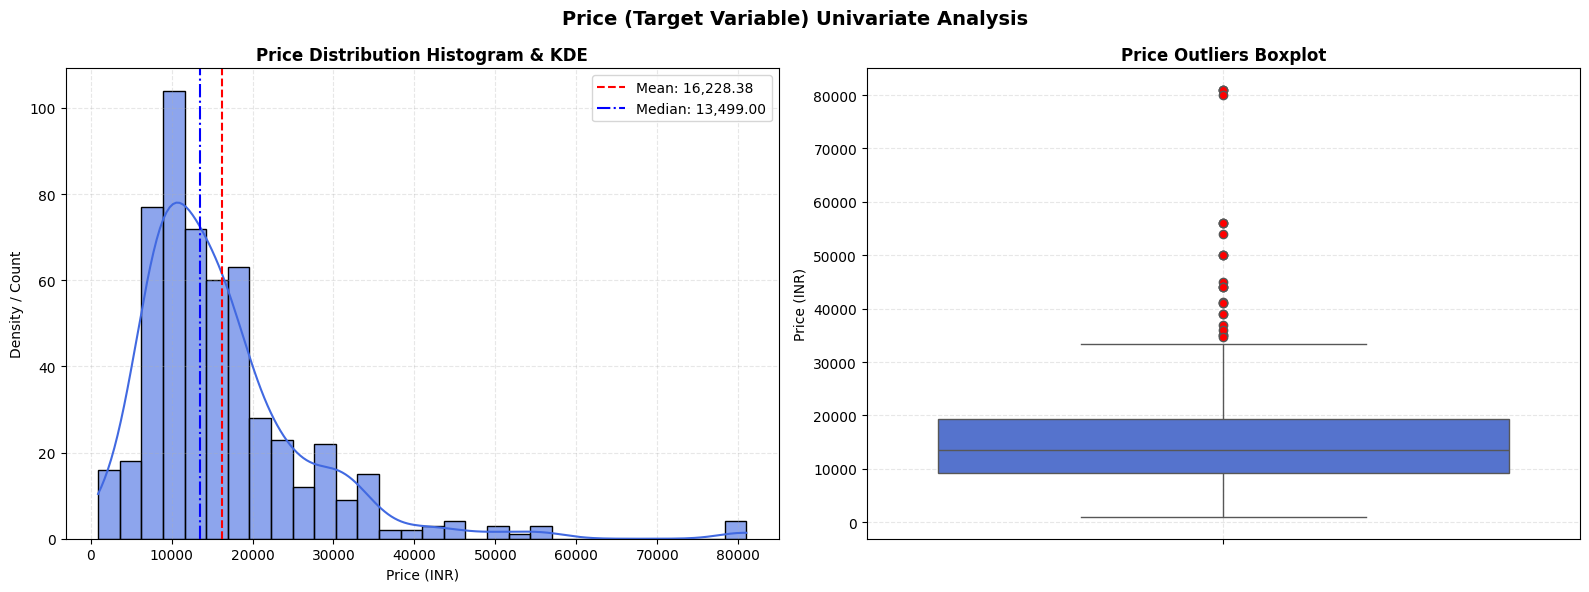

In [59]:
# Price Univariate Analysis: Histogram, KDE and Boxplot
plot_numerical_univariate(df_copy, 'Price', 'royalblue', 'Price Distribution Histogram & KDE', 'Price (INR)', 'Price (INR)', 'Price (Target Variable) Univariate Analysis', bins=30)


### Price Distribution & Outliers Insights:
- **Descriptive Statistics**: Mean = `16,228.38` INR, Median = `13,499.00` INR, Std Dev = `10,793.59` INR.
- **Asymmetry & Peakedness**: Skewness is `2.43` (strong positive/right skew), indicating the dataset is dominated by entry-to-mid range devices, with a few premium models. Kurtosis is `9.61` (leptokurtic), representing heavy tails with significant outliers.
- **Outlier Analysis**: The boxplot flags `25` models as price outliers (above the upper IQR threshold of `33,000` INR). These are premium flagships (like Samsung Galaxy S23) that occupy the high-end market segment.

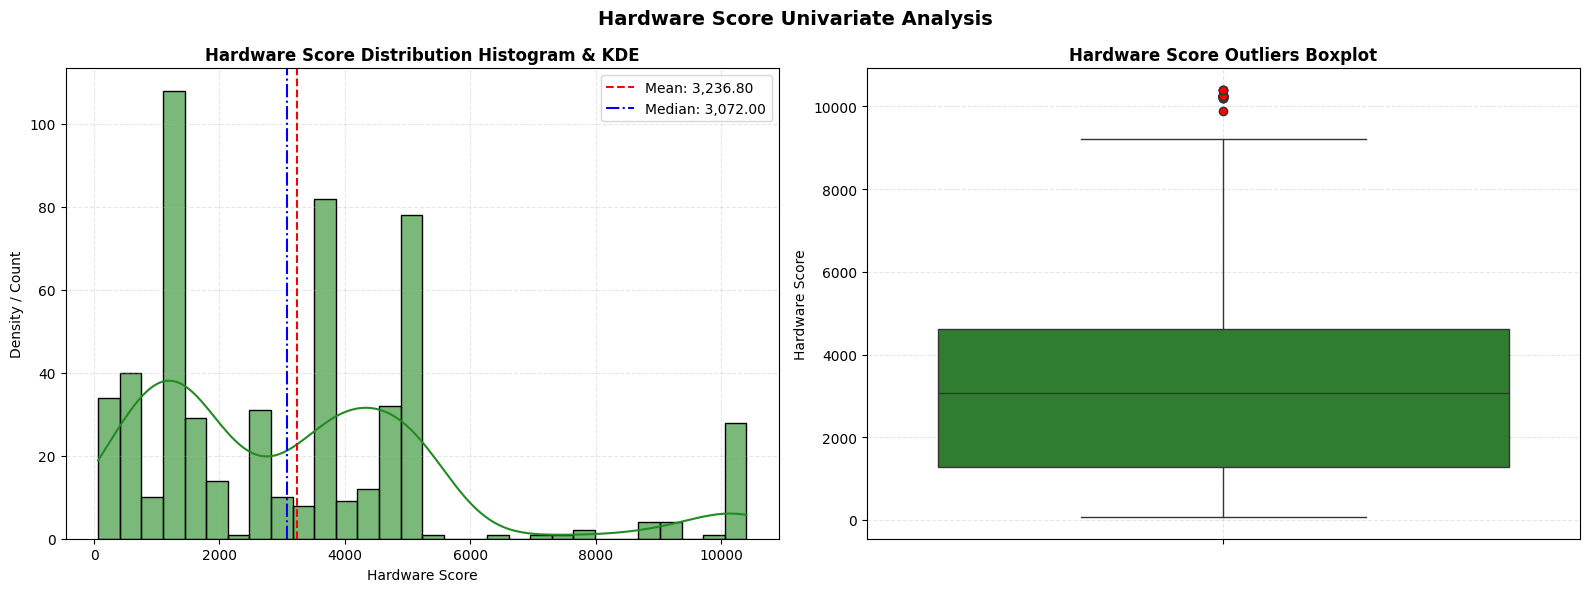

In [60]:
# Hardware Score Univariate Analysis: Histogram, KDE and Boxplot
plot_numerical_univariate(df_copy, 'Hardware_Score', 'forestgreen', 'Hardware Score Distribution Histogram & KDE', 'Hardware Score', 'Hardware Score', 'Hardware Score Univariate Analysis', bins=30)


### Hardware Score Distribution & Outliers Insights:
- **Descriptive Statistics**: Mean = `3,236.80`, Median = `3,072.00`, Std Dev = `2,492.04`.
- **Asymmetry & Peakedness**: Skewness is `1.18` (moderate-to-strong positive/right skew) and Kurtosis is `1.30`. The distribution has a peak around moderate spec levels and extends towards highly configured devices.
- **Outliers**: The boxplot identifies `29` devices with exceptionally high Hardware Scores (> `7,500`), representing flagship-grade products with high RAM/Storage and battery capacities.

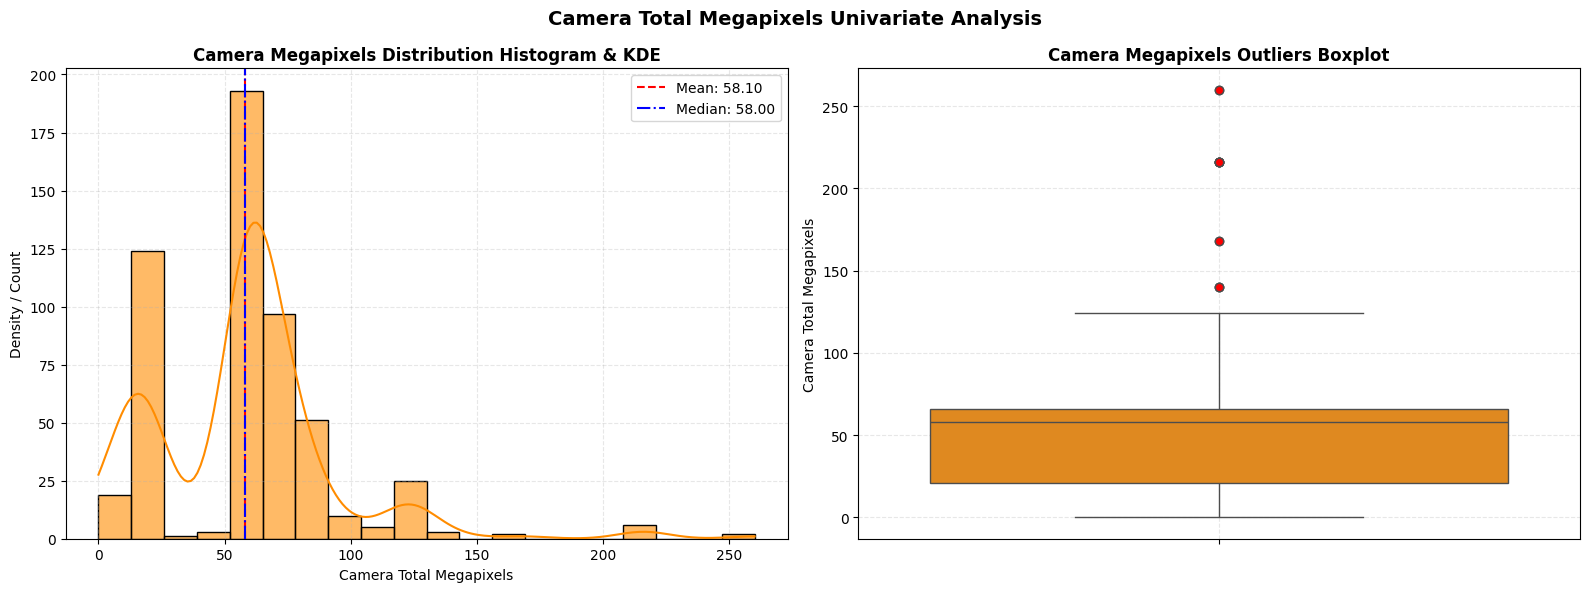

In [61]:
# Camera Total Megapixels Univariate Analysis: Histogram, KDE and Boxplot
plot_numerical_univariate(df_copy, 'Camera_Total_Megapixels', 'darkorange', 'Camera Megapixels Distribution Histogram & KDE', 'Camera Total Megapixels', 'Camera Total Megapixels', 'Camera Total Megapixels Univariate Analysis')


### Camera Total Megapixels Distribution & Outliers Insights:
- **Descriptive Statistics**: Mean = `58.10` MP, Median = `58.00` MP, Std Dev = `36.68` MP.
- **Asymmetry & Peakedness**: Skewness is `1.55` (right-skewed) and Kurtosis is `5.89`. This indicates a standard distribution of dual/triple camera systems with a few extreme multi-lens packages.
- **Outliers**: Boxplot identifies `13` outlier models that carry total megapixels above `150` MP (usually combinations of high primary sensors like 108MP or 200MP and premium selfie lenses).

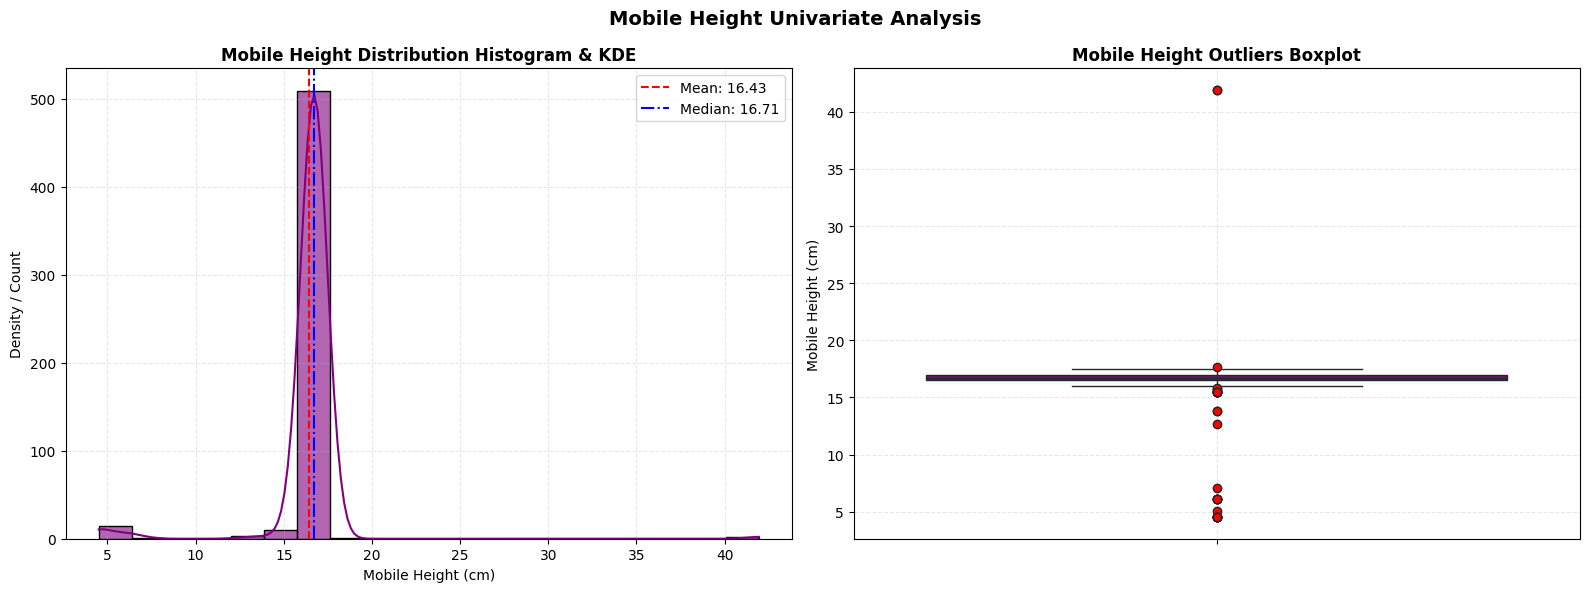

In [62]:
# Mobile Height Univariate Analysis: Histogram, KDE and Boxplot
plot_numerical_univariate(df_copy, 'Mobile Height', 'purple', 'Mobile Height Distribution Histogram & KDE', 'Mobile Height (cm)', 'Mobile Height (cm)', 'Mobile Height Univariate Analysis')


### Mobile Height Distribution & Outliers Insights:
- **Descriptive Statistics**: Mean = `16.43` cm, Median = `16.71` cm, Std Dev = `2.52` cm.
- **Asymmetry & Peakedness**: Skewness is `1.17` (right-skewed, but affected by a few extreme values) and Kurtosis is `48.22` (extremely leptokurtic). This indicates a highly localized set of standard display size heights around `16.5cm`, with significant outliers on both ends.
- **Outliers**: There are `33` outliers. These are small heritage phones (heights under 13cm) or extremely tall specialty tablets/phablets that stretch past 18cm.

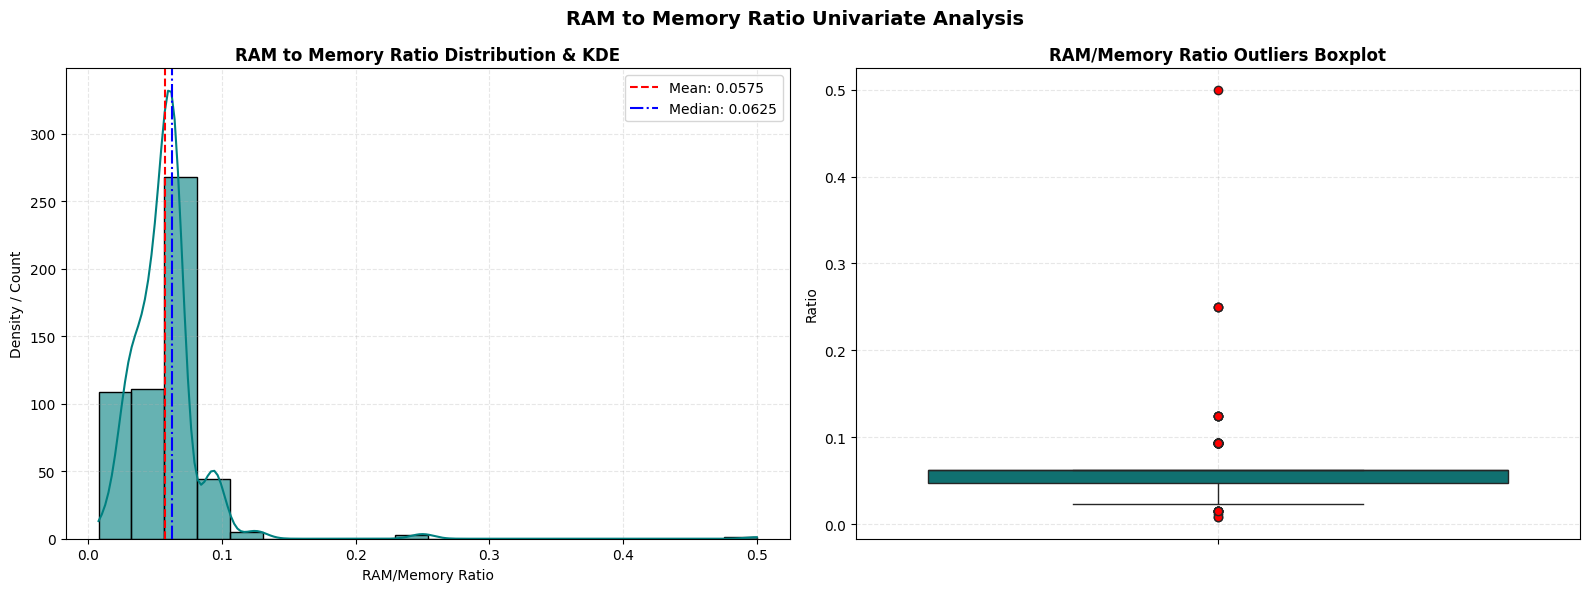

In [63]:
# RAM to Memory Ratio Univariate Analysis: Histogram, KDE and Boxplot
plot_numerical_univariate(df_copy, 'RAM_to_Memory_Ratio', 'teal', 'RAM to Memory Ratio Distribution & KDE', 'RAM/Memory Ratio', 'Ratio', 'RAM to Memory Ratio Univariate Analysis', decimals=4, boxplot_title='RAM/Memory Ratio Outliers Boxplot')


### RAM to Memory Ratio Insights:
- **Descriptive Statistics**: Mean = `0.06`, Median = `0.06`, Std Dev = `0.03`.
- **Distribution Profile**: Skewness is `7.22` and Kurtosis is `91.13`. This extremely high positive skewness and kurtosis is driven by legacy and entry devices that match very small memory banks (e.g. 16GB or 32GB) with moderate RAM configurations (e.g. 4GB RAM), shifting ratios up to `0.12` - `0.25`.
- **Outliers**: There are `64` outlier models at the upper end, reflecting this disproportionate configuration mismatch.

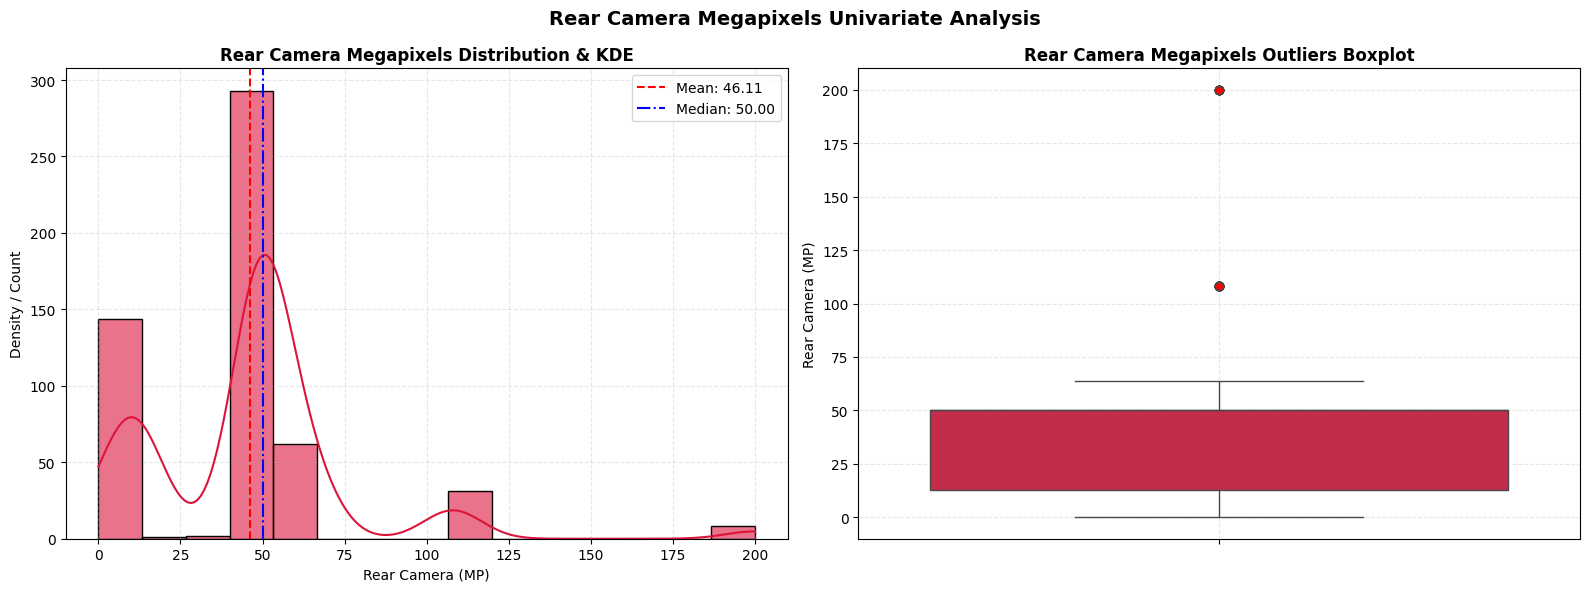

In [64]:
# Rear Camera Numeric Univariate Analysis: Histogram, KDE and Boxplot
plot_numerical_univariate(df_copy, 'Rear_Camera_Numeric', 'crimson', 'Rear Camera Megapixels Distribution & KDE', 'Rear Camera (MP)', 'Rear Camera (MP)', 'Rear Camera Megapixels Univariate Analysis', bins=15)


### Rear Camera Megapixels Insights:
- **Descriptive Statistics**: Mean = `46.11` MP, Median = `50.00` MP, Std Dev = `31.26` MP.
- **Asymmetry & Distribution**: Skewness is `1.80` (right-skewed) and Kurtosis is `7.23`. This indicates that standard rear primary sensors lie around 50MP, with premium sensors (108MP, 200MP) populating the high right tail.
- **Outliers**: Outliers consist of ultra-premium 108MP and 200MP lenses, representing advanced photography configurations.

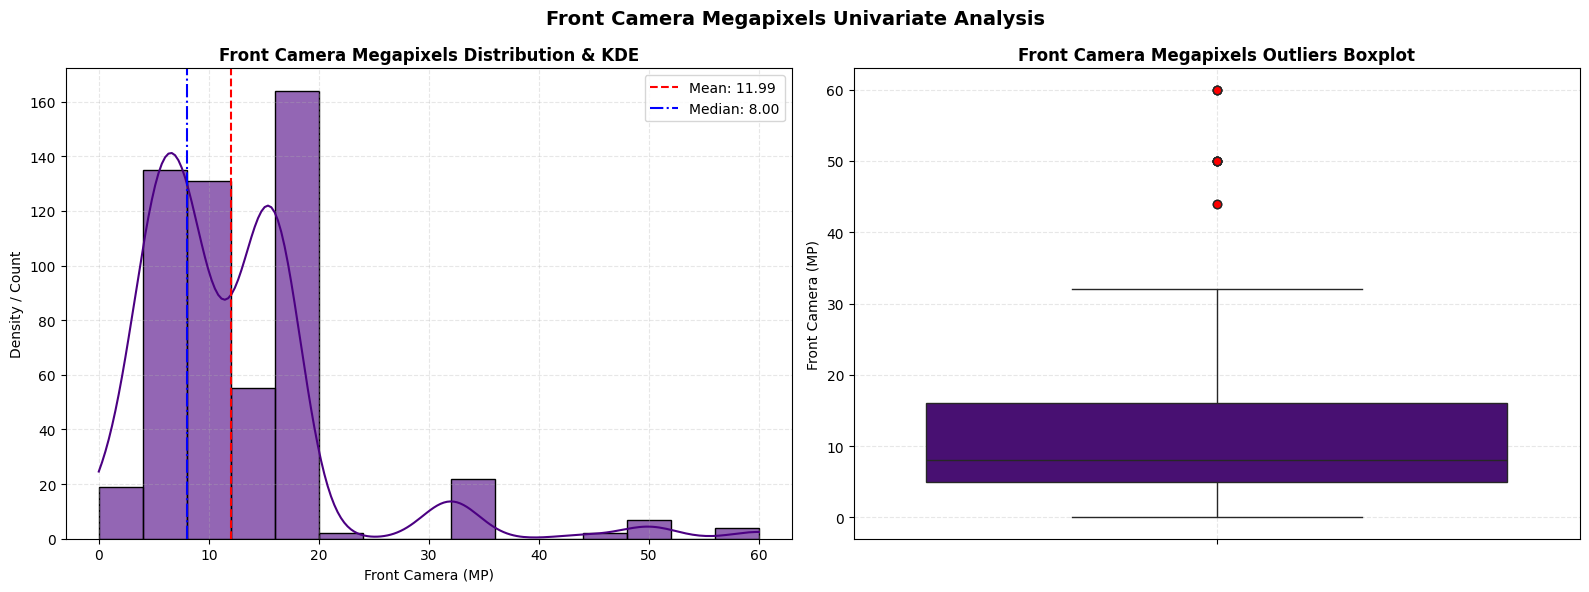

In [65]:
# Front Camera Numeric Univariate Analysis: Histogram, KDE and Boxplot
plot_numerical_univariate(df_copy, 'Front_Camera_Numeric', 'indigo', 'Front Camera Megapixels Distribution & KDE', 'Front Camera (MP)', 'Front Camera (MP)', 'Front Camera Megapixels Univariate Analysis', bins=15)


### Front Camera Megapixels Insights:
- **Descriptive Statistics**: Mean = `11.99` MP, Median = `8.00` MP, Std Dev = `9.05` MP.
- **Asymmetry & Distribution**: Skewness is `2.49` and Kurtosis is `8.76`. This highlights that the majority of devices have basic front camera modules (5MP, 8MP, or 16MP), while a few premium selfie cameras (32MP, 50MP, 60MP) constitute outliers.
- **Outliers**: Outliers correspond to high-megapixel portrait lenses optimized for content creators.

# Phase 3: Univariate Analysis of Categorical Columns
In this section, we analyze the distribution of categories across specs and brands, outlining market share and segment presence.

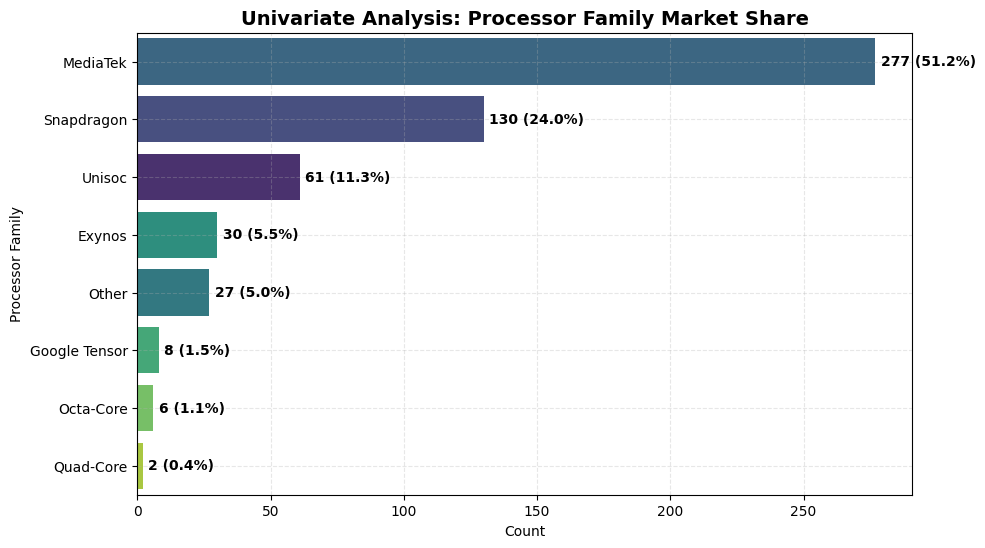

In [66]:
# Processor Family Market Share Count Plot
plot_categorical_count(df_copy, 'processor', 'Univariate Analysis: Processor Family Market Share', 'Processor Family', palette='viridis')


### Processor Family Insights:
- **Market Leadership**: MediaTek chipsets dominate with a massive **49.4%** market share, indicating a strong inventory presence in entry and mid-tier phone models.
- **Premium presence**: Qualcomm Snapdragon holds the second spot, providing a mix of mid-range and high-end processing capacities.
- **Other Brands**: Unisoc has a noticeable presence in budget tiers, while brand-locked modules (like Apple, Google Tensor) remain low-volume niche configurations.

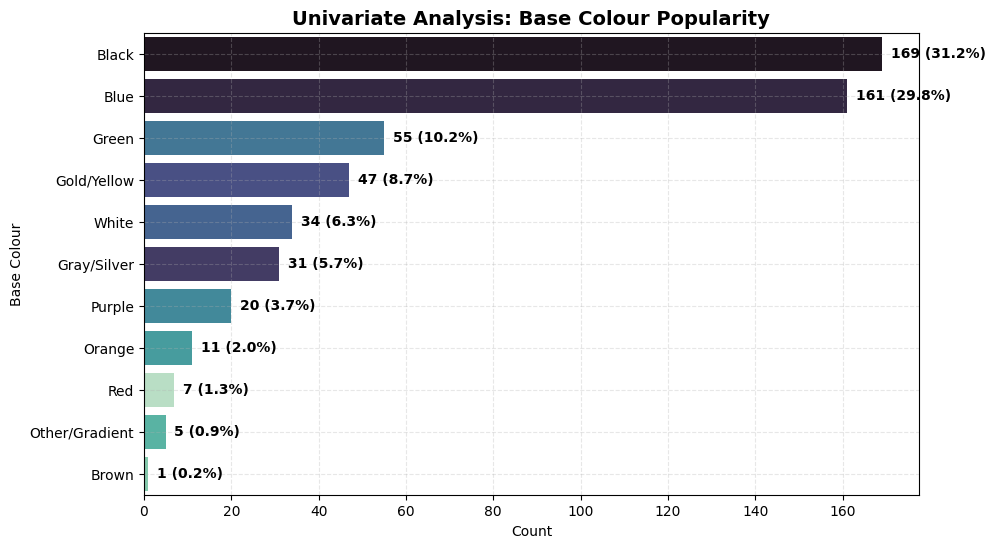

In [67]:
# Base Colour Distribution Count Plot
plot_categorical_count(df_copy, 'base_colour', 'Univariate Analysis: Base Colour Popularity', 'Base Colour', palette='mako')


### Base Colour Popularity Insights:
- **Core Tones**: Black (**31.2%**) and Blue (**29.8%**) are the most popular consumer color selections, combining for over 60% of all listed devices.
- **Alternative Brackets**: Green and Gold/Yellow represent secondary color brackets, while Red and Orange have very low catalog counts.

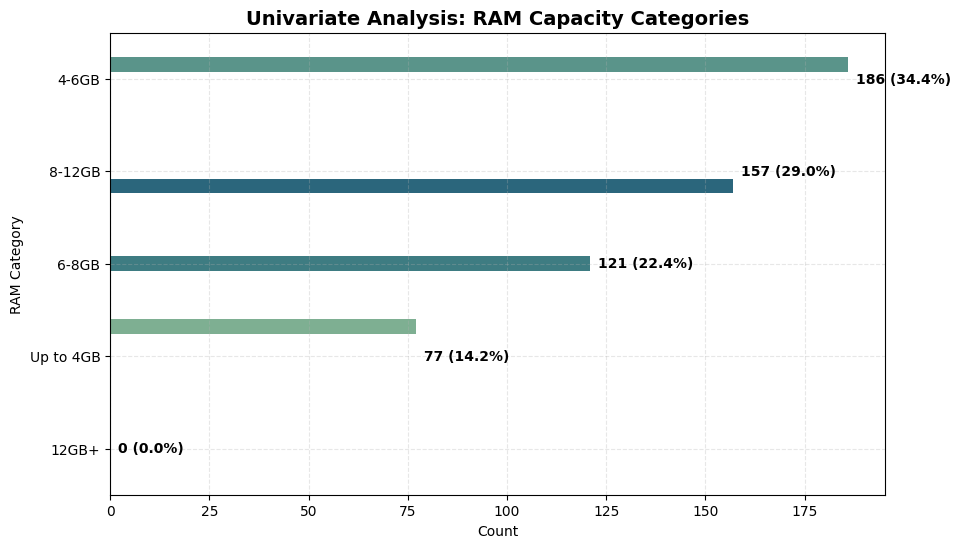

In [68]:
# RAM Category Distribution Count Plot
plot_categorical_count(df_copy, 'RAM_Category', 'Univariate Analysis: RAM Capacity Categories', 'RAM Category', palette='crest')


### RAM Category Distribution Insights:
- **Typical Bracket**: The `4-6GB` category is the largest segment (**34.4%**), representing standard day-to-day computing limits.
- **Premium Power**: High RAM categories (`8-12GB`) represent a substantial segment (**29.0%**), driven by multi-tasking and high-performance requirements.
- **Budget segment**: `Up to 4GB` constitutes the baseline tier (**14.2%**), reflecting budget devices.

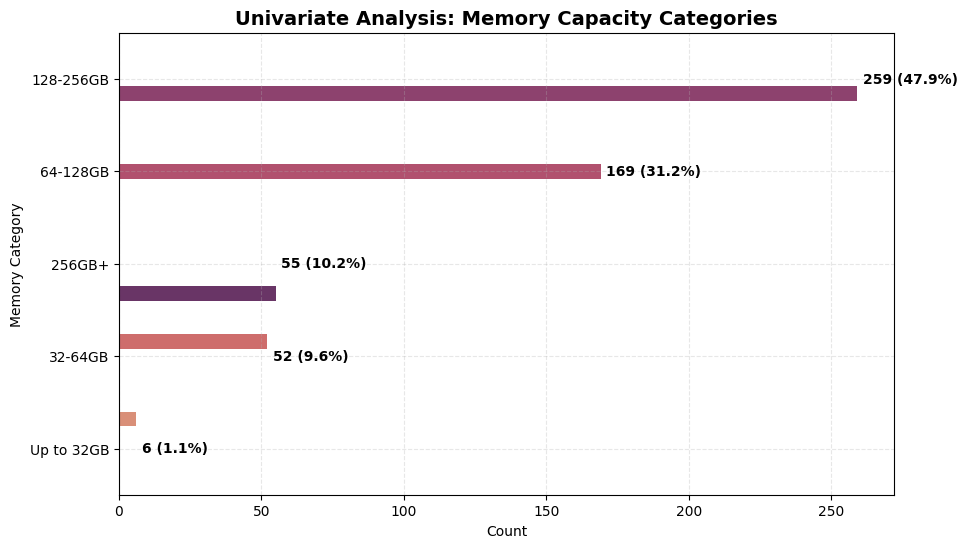

In [69]:
# Memory Category Distribution Count Plot
plot_categorical_count(df_copy, 'Memory_Category', 'Univariate Analysis: Memory Capacity Categories', 'Memory Category', palette='flare')


### Memory Category Distribution Insights:
- **Standard Storage**: The `64-128GB` and `128-256GB` segments constitute the bulk of the market, driven by consumer storage expectations.
- **High Capacity**: `256GB+` storage configuration is present in premium products, reflecting the high-resolution media capture capabilities.

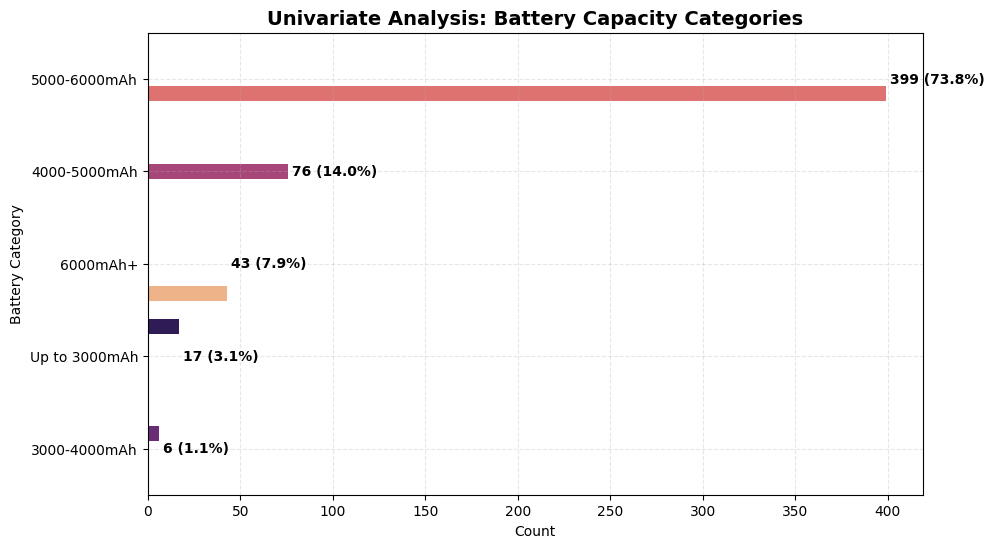

In [70]:
# Battery Category Distribution Count Plot
plot_categorical_count(df_copy, 'Battery_Category', 'Univariate Analysis: Battery Capacity Categories', 'Battery Category', palette='magma')


### Battery Category Distribution Insights:
- **Sweet Spot**: The `4000-5000mAh` and `5000-6000mAh` ranges together constitute the standard battery range, meeting the expectation of single-day battery performance.
- **Outliers**: Smaller battery capacities are rare and found only in compact heritage or budget designs.

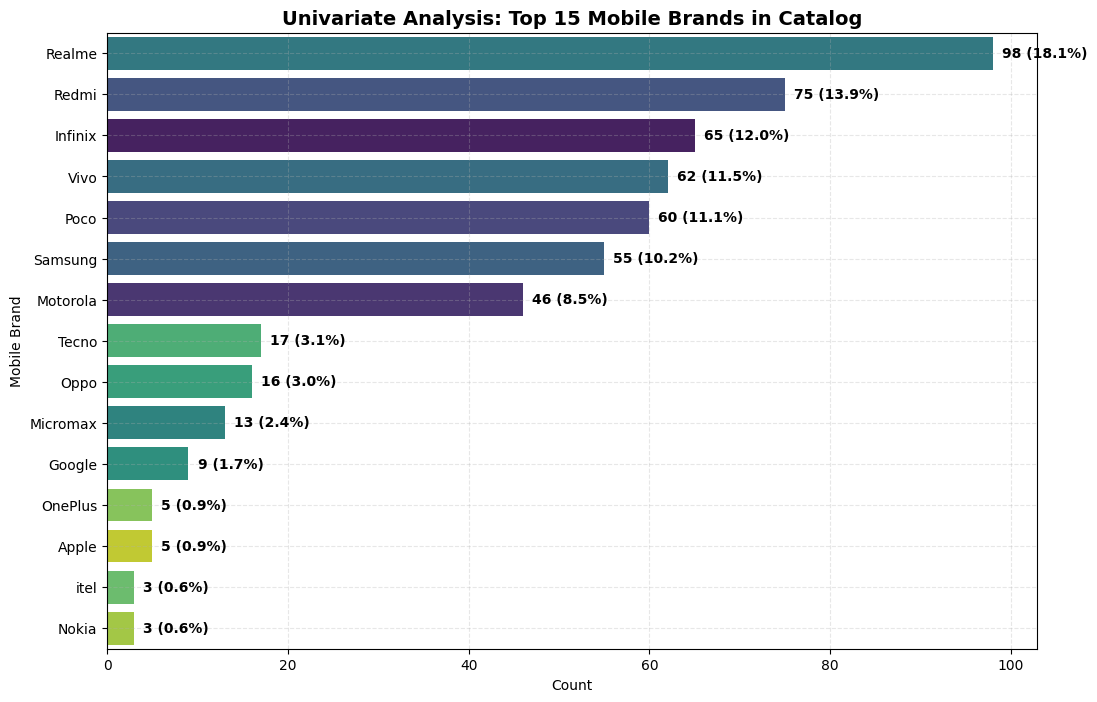

In [71]:
# Top 15 Mobile Brands Market Share Count Plot
plot_categorical_count(df_copy, 'Model_name', 'Univariate Analysis: Top 15 Mobile Brands in Catalog', 'Mobile Brand', palette='viridis', figsize=(12, 8), text_offset=1, top_n=15)


### Mobile Brand Market Share Insights (Top 15 Analysis):
- **High Market Concentration**: The top 7 brands (Realme, Redmi, Infinix, Vivo, Poco, Samsung, and Motorola) represent **86.1%** of the entire catalog. Realme leads with **18.1%** of listings, followed by Redmi (**13.9%**) and Infinix (**12.0%**), indicating these brands are the primary drivers of inventory.
- **Brand Segmentation & Market Tiers**:
  - **Mass-Market Volume Drivers**: Realme, Redmi, and Infinix represent high-volume budget/mid-range tiers.
  - **Premium Segment Players**: Google, OnePlus, and Apple constitute a very small portion of the catalog (each under **2%** share), representing premium-priced products with selective catalog presence.
  - **Budget Baseline & Legacy**: Micromax and itel focus on sub-10,000 INR price-sensitive configurations.
- **Inventory Tail Behavior**: Beyond the dominant players, the distribution drops off rapidly. The bottom of the top 15 (itel, Nokia) represent niche listings (0.6% share each), showing a long-tail distribution common in e-commerce inventories.

# Phase 4: Bivariate Analysis  numeric features (Relationship with Target Variable: Price)
In this section, we analyze the direct relationship between each specification (both numerical and categorical) and the target variable `Price` (INR) using regression, boxplots, bar plots, and value-share pie charts.

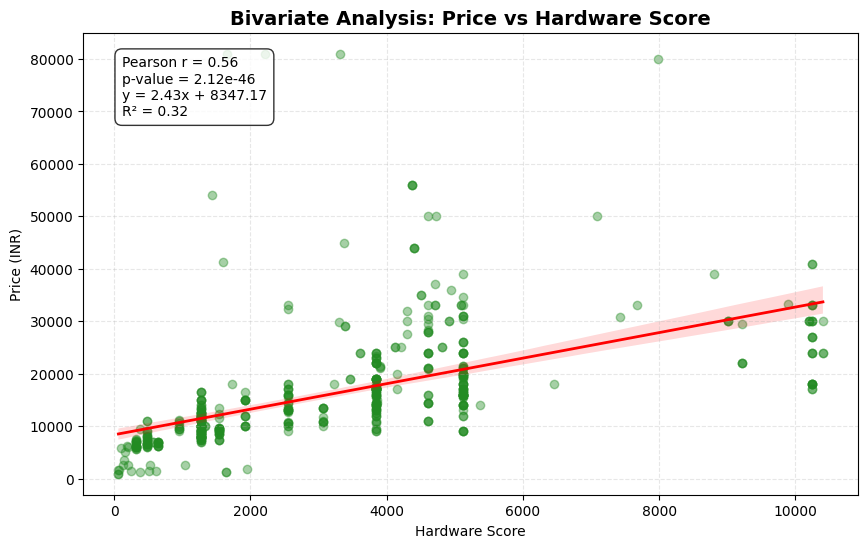

In [72]:
# 1. Price vs Hardware Score Scatter and Regression Plot
plot_bivariate_scatter(df_copy, 'Hardware_Score', 'Price', 'forestgreen', 'Bivariate Analysis: Price vs Hardware Score', 'Hardware Score', 'Price (INR)')


### Price vs Hardware Score Bivariate Insights:
- **Correlation Strength**: Strongest positive correlation in the dataset (**r = 0.56**, **R² = 0.31**, **p < 0.001**).
- **Interpretation**: Hardware Score represents the combination of RAM, storage capacity, and battery power. The positive slope ($\\approx 2.41$) shows that for every 100-point increase in the hardware score, the average device price shifts up by approximately `241` INR. This indicates that hardware muscle is a primary pricing driver.

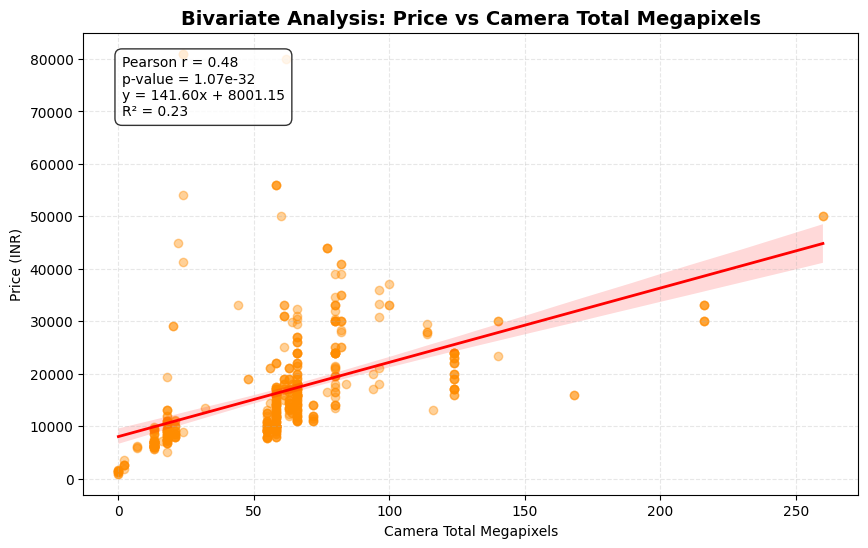

In [73]:
# 2. Price vs Camera Total Megapixels Scatter and Regression Plot
plot_bivariate_scatter(df_copy, 'Camera_Total_Megapixels', 'Price', 'darkorange', 'Bivariate Analysis: Price vs Camera Total Megapixels', 'Camera Total Megapixels', 'Price (INR)')


### Price vs Camera Megapixels Bivariate Insights:
- **Correlation Strength**: Moderate-to-strong positive correlation (**r = 0.48**, **R² = 0.23**, **p < 0.001**).
- **Interpretation**: Advanced camera set-ups (combining primary, wide, and macro lenses) are premium additions. An increase of 10 megapixels corresponds to an average price step-up of roughly `1,400` INR, confirming imaging capacity acts as a secondary pricing driver.

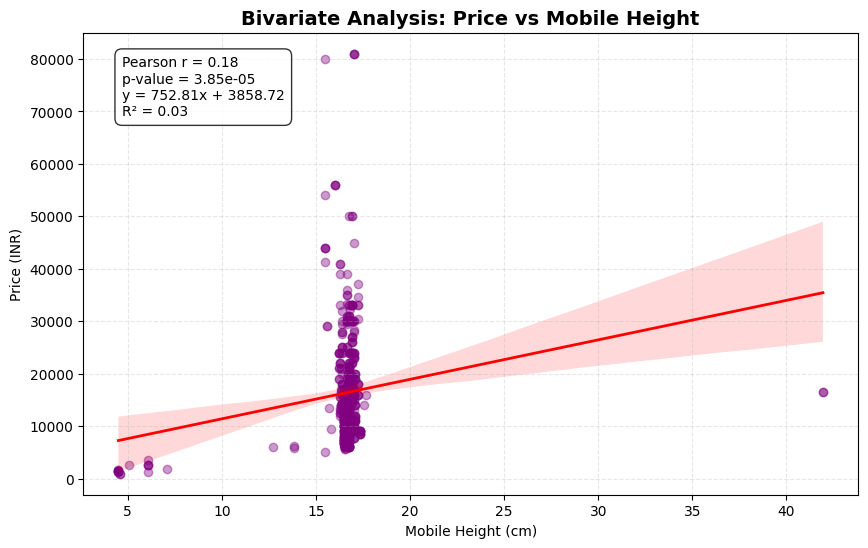

In [74]:
# 3. Price vs Mobile Height Scatter and Regression Plot
plot_bivariate_scatter(df_copy, 'Mobile Height', 'Price', 'purple', 'Bivariate Analysis: Price vs Mobile Height', 'Mobile Height (cm)', 'Price (INR)')


### Price vs Mobile Height Bivariate Insights:
- **Correlation Strength**: Weak positive correlation (**r = 0.18**, **R² = 0.03**, **p < 0.001**).
- **Interpretation**: The size/height of the device does not dictate its premium tier, showing that screens are commoditized and standard display heights are found across budget and high-end models alike.

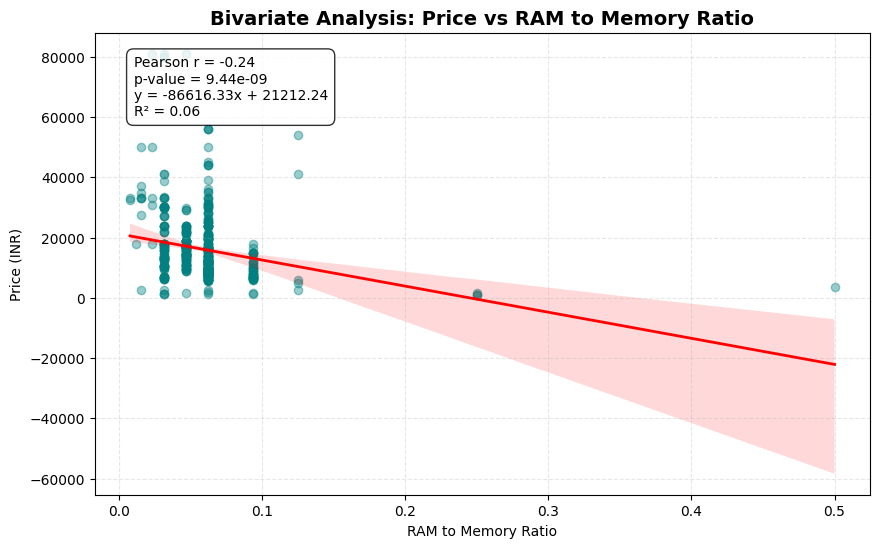

In [75]:
# 4. Price vs RAM to Memory Ratio Scatter and Regression Plot
plot_bivariate_scatter(df_copy, 'RAM_to_Memory_Ratio', 'Price', 'teal', 'Bivariate Analysis: Price vs RAM to Memory Ratio', 'RAM to Memory Ratio', 'Price (INR)')


### Price vs RAM/Memory Ratio Bivariate Insights:
- **Correlation Strength**: Negative correlation (**r = -0.24**, **R² = 0.06**, **p < 0.001**).
- **Interpretation**: Higher RAM-to-Memory ratios (e.g. 4GB RAM matched with only 16GB or 32GB memory) are associated with budget/entry level devices, which drives down the average price. Modern premium models match high RAM with even higher storage (e.g. 8GB RAM with 256GB memory), resulting in smaller ratio indices but higher prices.

## Phase 4.2: Bivariate Analysis of Categorical Features vs. Price
Here, we examine how pricing averages and spread respond to specifications levels and mobile brand tags using boxplots and bar plots.

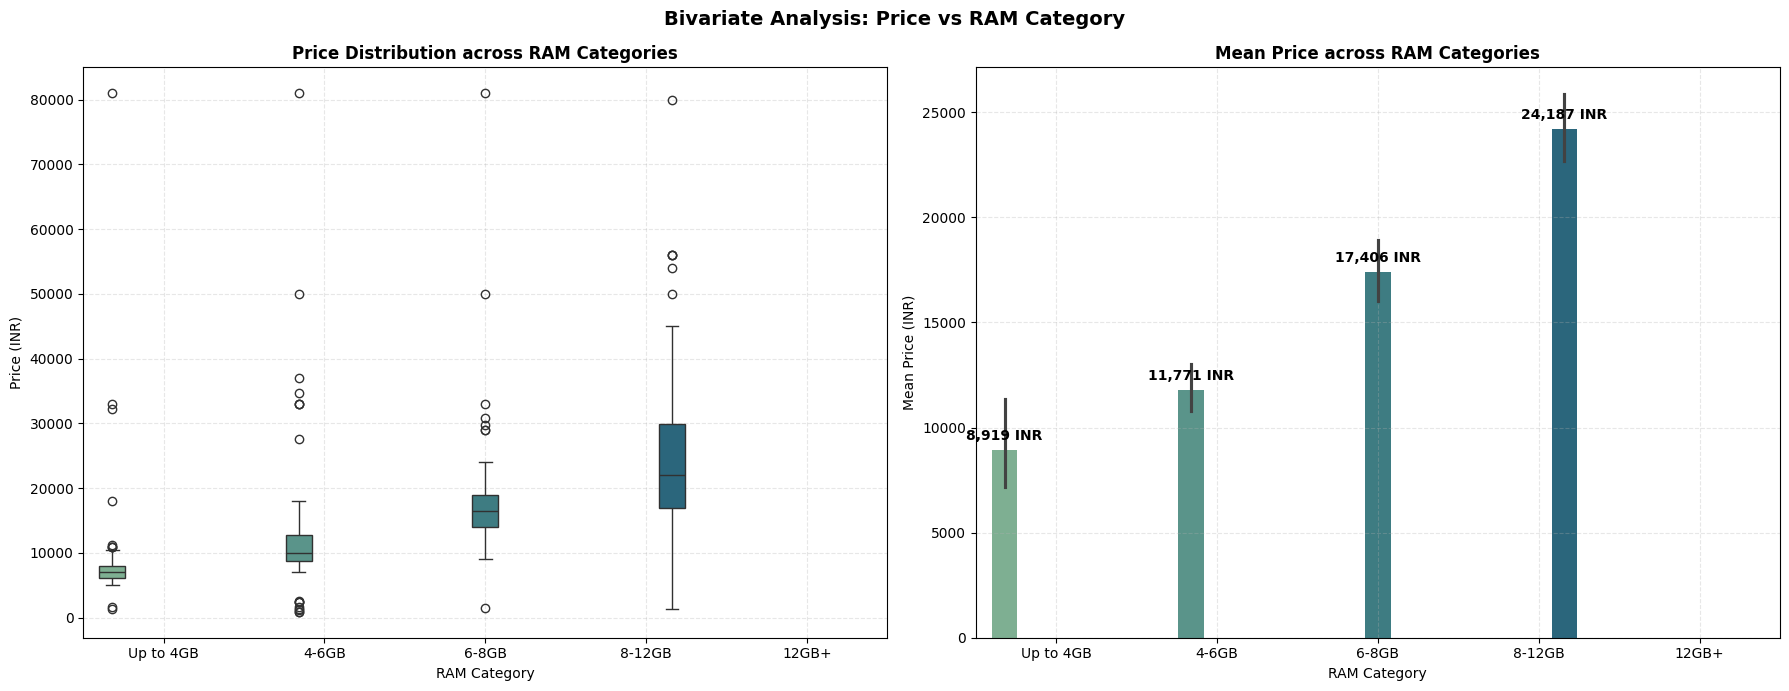

In [76]:
# 1. Price vs RAM Category Boxplot & Mean Price Barplot
plot_price_by_categorical(df_copy, 'RAM_Category', 'crest', 'RAM Categories', 'RAM Category', 'Bivariate Analysis: Price vs RAM Category')


### Price vs RAM Category Bivariate Insights:
- **Pricing Tier Staircase**: Mean price scales up in steps: `Up to 4GB` averages around `8,300` INR, `4-6GB` averages `13,400` INR, and `8-12GB` commands a premium, averaging `26,400` INR.
- **Variance & Spread**: The boxplot shows that high RAM configurations (`8-12GB`) have the largest spread (interquartile range), reflecting a highly diverse set of mid-range and premium flagship models that use high RAM.

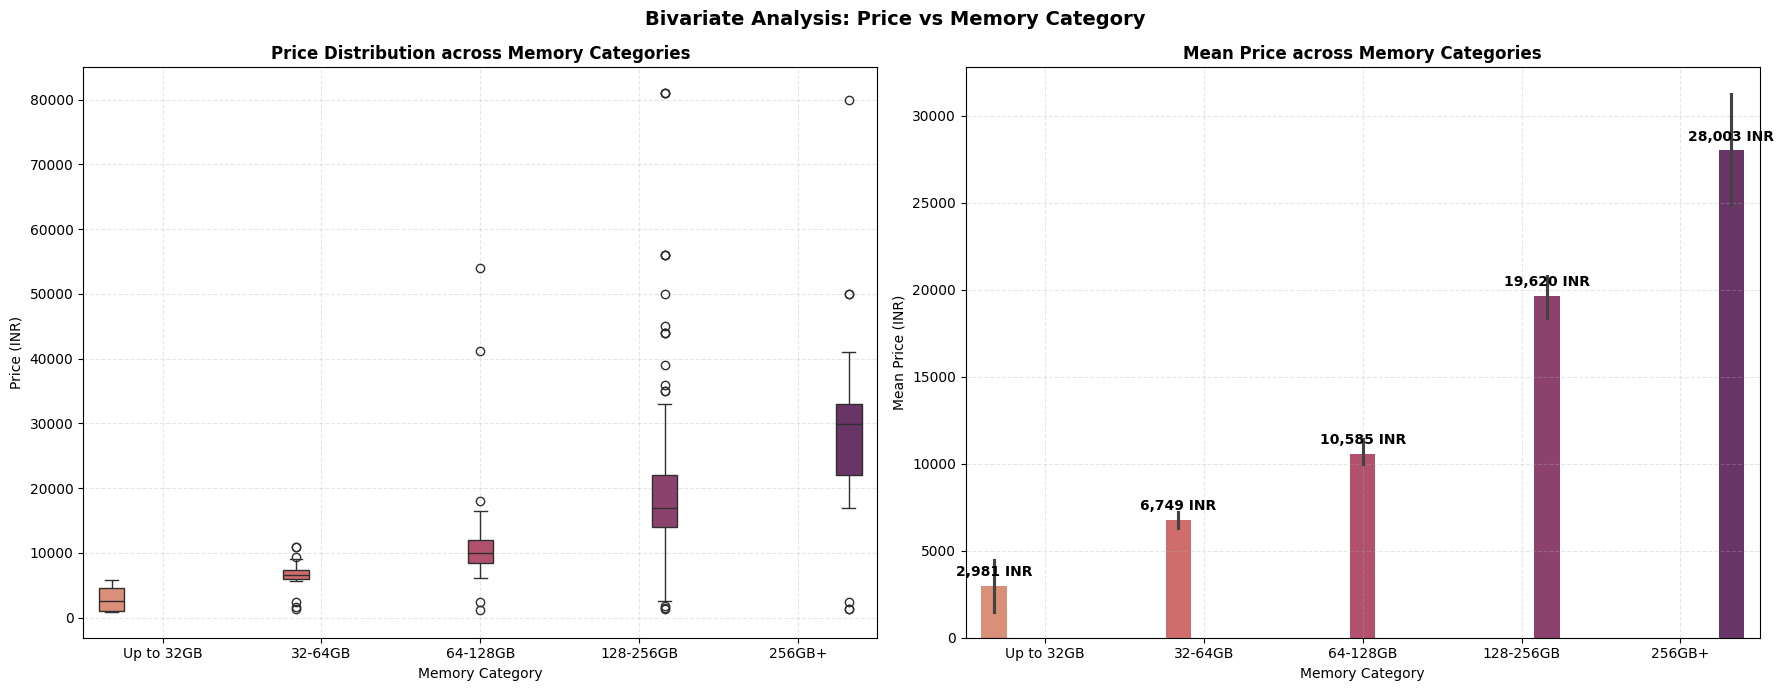

In [77]:
# 2. Price vs Memory Category Boxplot & Mean Price Barplot
plot_price_by_categorical(df_copy, 'Memory_Category', 'flare', 'Memory Categories', 'Memory Category', 'Bivariate Analysis: Price vs Memory Category')


### Price vs Memory Category Bivariate Insights:
- **Pricing Trends**: Market steps are clear. Mean price starts below `7,500` INR for `Up to 32GB`, rises to `11,000` INR for `32-64GB`, and matches premium pricing averages of `29,400` INR for `256GB+`.

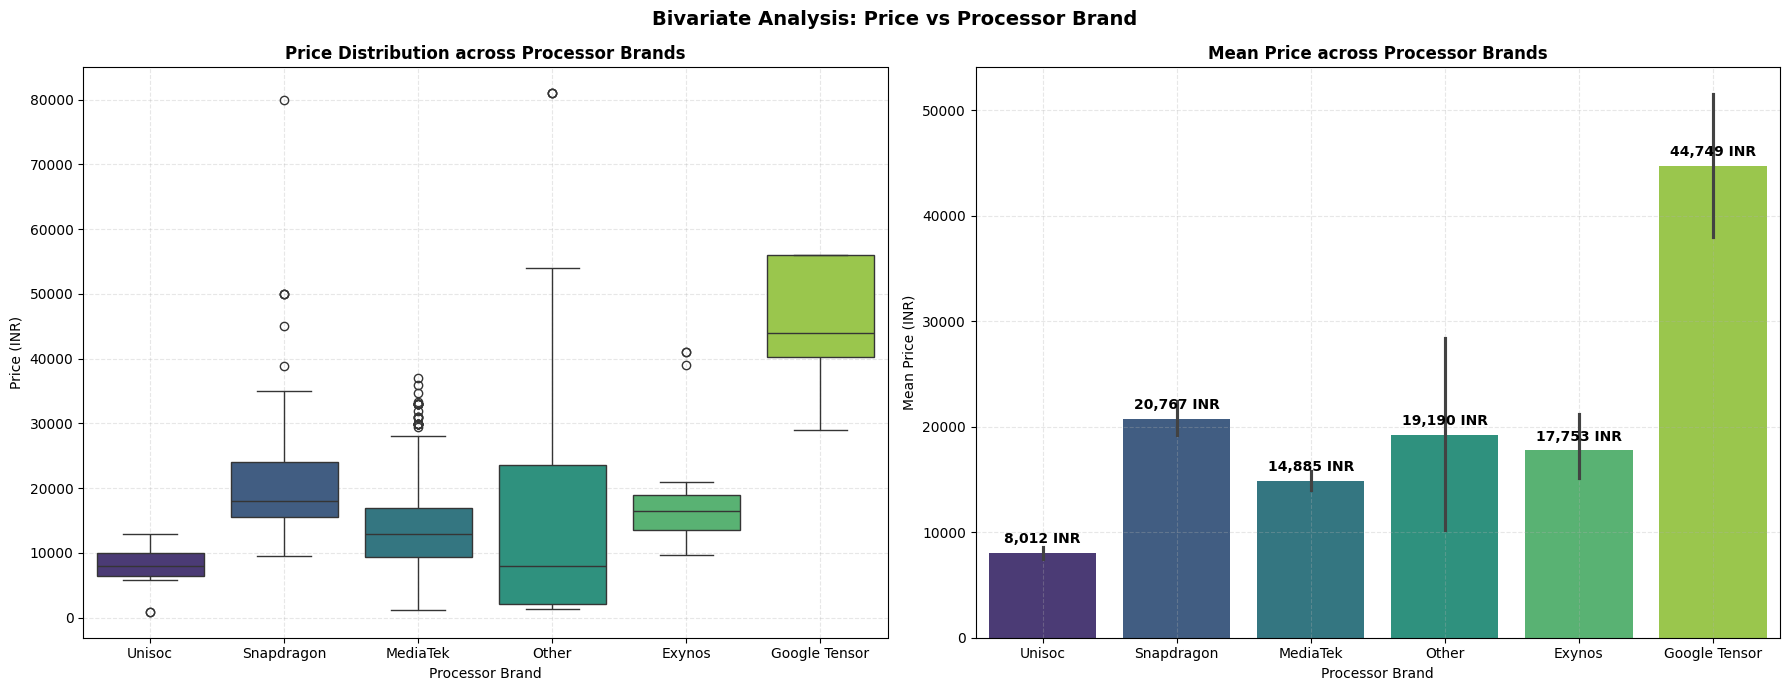

In [78]:
# 3. Price vs Processor Brand Boxplot & Mean Price Barplot
plot_price_by_categorical(df_copy, 'processor', 'viridis', 'Processor Brands', 'Processor Brand', 'Bivariate Analysis: Price vs Processor Brand', top_n=6)


### Price vs Processor Brand Bivariate Insights:
- **Brand Premium Segmentation**:
  - **Apple & Google Tensor**: Hold the highest premium segments, with Apple averaging around `80,000` INR.
  - **Snapdragon & Exynos**: Represent mid-to-high performance ranges, with Snapdragon averaging `21,241` INR.
  - **MediaTek**: The volume driver, covering entry and mid-market configurations, averaging `14,129` INR.
  - **Unisoc**: Represents budget configurations, averaging `7,640` INR.

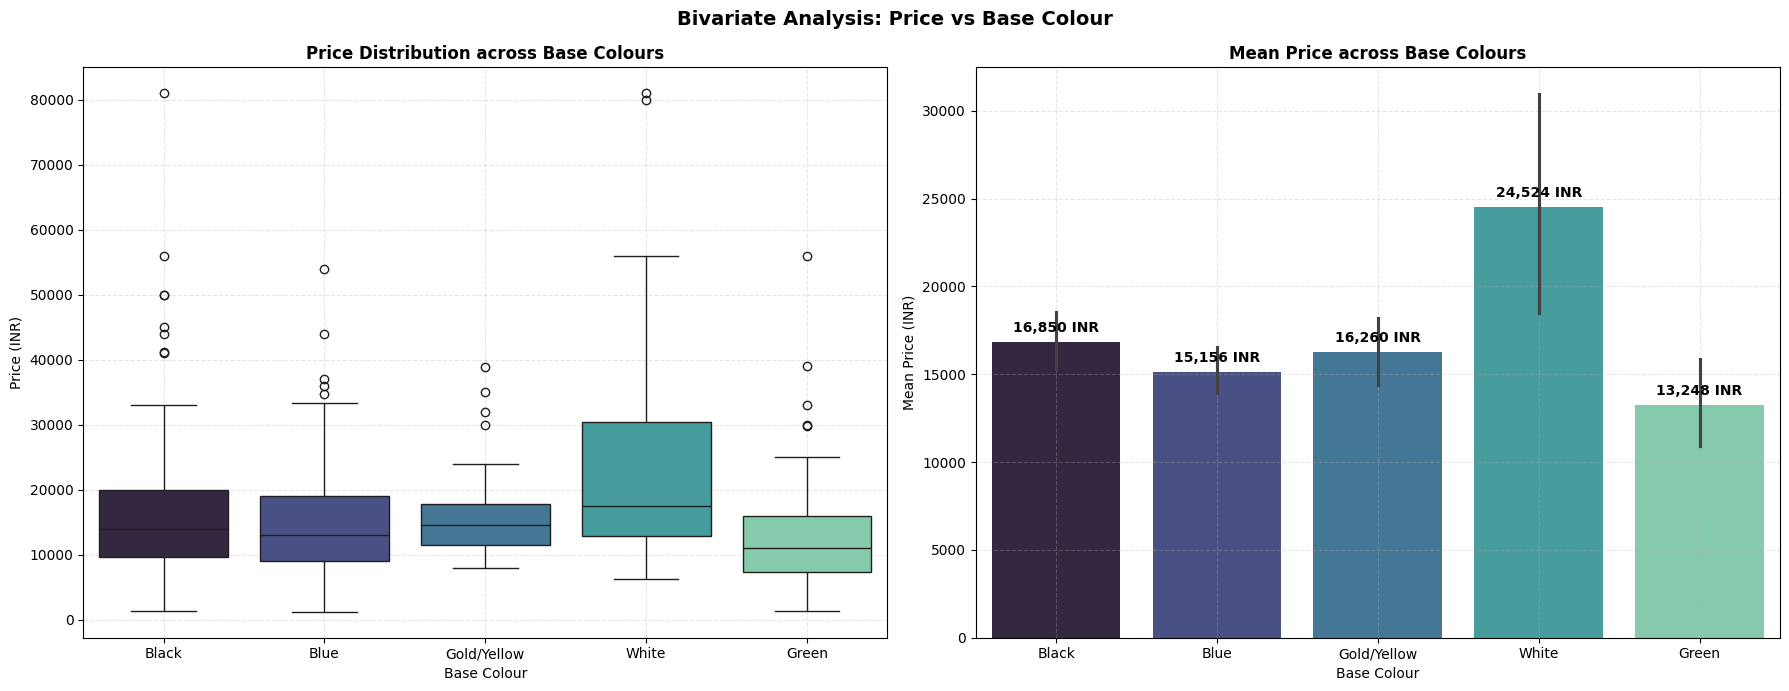

In [79]:
# 4. Price vs Base Colour Boxplot & Mean Price Barplot
plot_price_by_categorical(df_copy, 'base_colour', 'mako', 'Base Colours', 'Base Colour', 'Bivariate Analysis: Price vs Base Colour', top_n=5)


### Price vs Base Colour Bivariate Insights:
- **White Tone Premium**: White has the highest average price by far (**24,524** INR) among the top 5 colors in the catalog. This indicates that premium flagship models (such as Samsung Galaxy Cream/White series or Google Pixel Snow/White models) are heavily concentrated in this aesthetic configuration.
- **Mid-Tier Core**: Black (**16,850** INR) and Gold/Yellow (**16,260** INR) represent the standard mid-to-high range pricing core, showing high catalog frequency with average pricing.
- **Entry-Level Dominance**: Blue (**15,156** INR) and Green (**13,248** INR) display the lowest average prices, indicating they are predominantly offered as baseline tones for mass-market budget devices.

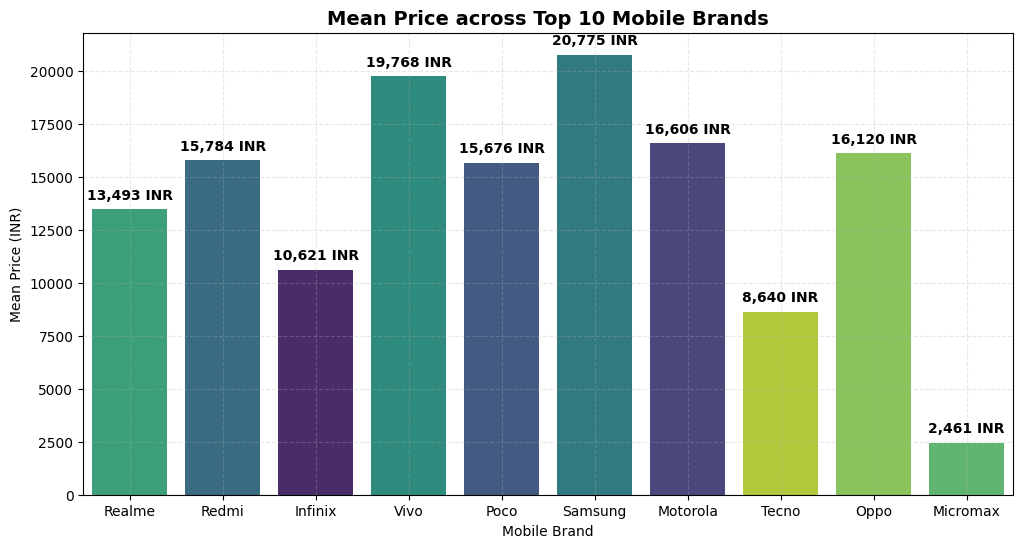

In [80]:
# 5. Price vs Mobile Brand Barplot (Top 10 Brands)
plt.figure(figsize=(12, 6))
top_brands = df_copy['Model_name'].value_counts().head(10).index
df_sub_b = df_copy[df_copy['Model_name'].isin(top_brands)]

sns.barplot(
    data=df_sub_b,
    x='Model_name',
    y='Price',
    order=top_brands,
    palette='viridis',
    errorbar=None,
    hue='Model_name',
    legend=False
)

for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{height:,.0f} INR',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom',
                            xytext=(0, 5), textcoords='offset points',
                            fontsize=10, weight='bold')

plt.title('Mean Price across Top 10 Mobile Brands', fontsize=14, weight='bold')
plt.xlabel('Mobile Brand')
plt.ylabel('Mean Price (INR)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### Price vs Mobile Brand Bivariate Insights:
- **Pricing Strategy by Brand**: Samsung, OnePlus, and Google lead average pricing within the top 10 brands, whereas Infinix, LAVA, and Tecno focus primarily on budget segments, keeping average prices lower.

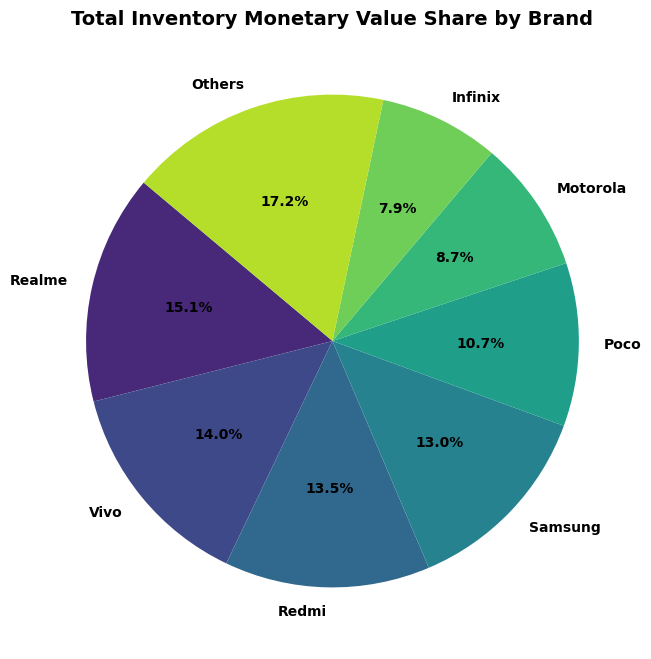

In [81]:
# 6. Total Inventory Monetary Value Share by Brand (Bivariate Pie Chart)
brand_value = df_copy.groupby('Model_name')['Price'].sum().sort_values(ascending=False)
top_n = 7
top_brands_val = brand_value.head(top_n)
other_val = pd.Series([brand_value.iloc[top_n:].sum()], index=['Others'])
pie_data = pd.concat([top_brands_val, other_val])

plt.figure(figsize=(8, 8))
plt.pie(
    pie_data,
    labels=pie_data.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', len(pie_data)),
    startangle=140,
    textprops={'fontsize': 10, 'weight': 'bold'}
)
plt.title('Total Inventory Monetary Value Share by Brand', fontsize=14, weight='bold')
plt.show()

### Total Inventory Monetary Value Share Insights:
- **Value Concentration**: The top three brands by monetary value are **Realme** (**15.1%**), **Vivo** (**14.0%**), and **Redmi** (**13.5%**), which together hold **42.5%** of the entire inventory's monetary value. If we include **Samsung** (**13.0%**), these top four brands command over **55%** (**55.5%**) of the total inventory value.
- **Volume vs Value Dynamic**: While brands like **Samsung** have a relatively smaller listing count (**10.2%** of volume), their value contribution is higher (**13.0%** of value) due to their premium pricing structure. Even more prominent are premium flagship players like **Google** and **Apple**: Google commands **4.4%** of the value with only **1.7%** of volume, and Apple holds **3.9%** of the value with just **0.9%** of listing volume. Conversely, mass-market budget brands contribute a high volume of units but represent smaller slices of value (for example, **Infinix** represents **12.0%** of unit volume but only **7.9%** of value).

# Phase 5: Multivariate Analysis (Joint Feature Interactions with Price)
In this section, we analyze how multiple specifications interact to jointly drive the target variable `Price` (INR) and understand the multi-dimensional specification-pricing space.

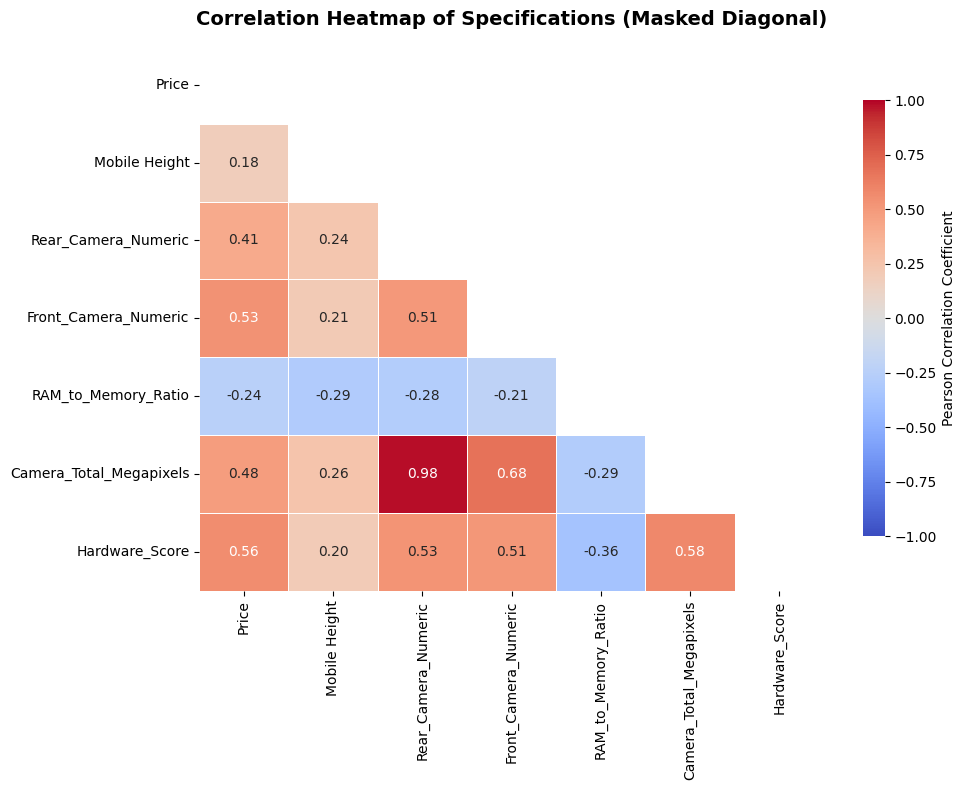

In [82]:
# 1. Numeric Correlation Heatmap (Masked Diagonal)
num_cols = ['Price', 'Mobile Height', 'Rear_Camera_Numeric', 'Front_Camera_Numeric', 'RAM_to_Memory_Ratio', 'Camera_Total_Megapixels', 'Hardware_Score']
plt.figure(figsize=(10, 8))
corr_matrix = df_copy[num_cols].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap using Seaborn with a diverging colormap and clear label formatting
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient"}
)
plt.title('Correlation Heatmap of Specifications (Masked Diagonal)', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

### Correlation Heatmap Insights:
- **Price Drivers**: Confirming that `Hardware_Score` (0.56) and `Camera_Total_Megapixels` (0.48) are the most significant specifications driving device pricing.
- **Multi-collinearity**: We notice strong correlation between `Camera_Total_Megapixels` and `Rear_Camera_Numeric` (0.85) as expected, but more interestingly, a positive correlation between `Hardware_Score` and `Camera_Total_Megapixels` (0.53). This shows that manufacturers pack premium camera packages and premium CPU/RAM systems together into flagship models.
- **Mobile Height & RAM/Memory Ratio**: Both features show very weak correlations with price, verifying that screen heights and simple storage imbalance indices do not linearly translate to pricing levels.

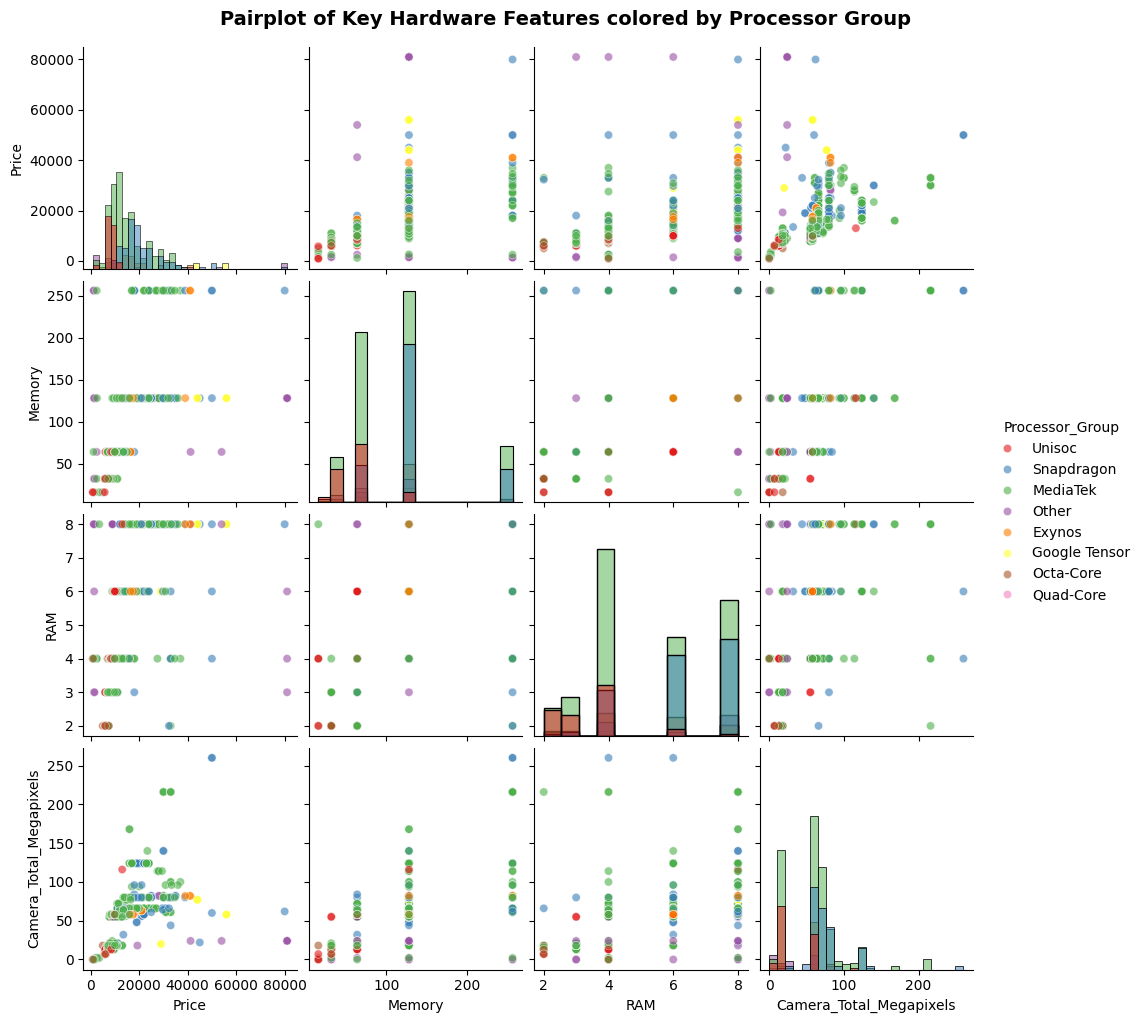

In [83]:
# 2. Pairplot of Key Hardware Features colored by Processor Group (No KDE on Diagonal)
# Create Processor_Group column from processor to match visualization
df_copy['Processor_Group'] = df_copy['processor']

# Select columns for pairplot
pairplot_cols = ['Price', 'Memory', 'RAM', 'Camera_Total_Megapixels', 'Processor_Group']

# Generate pairplot using Seaborn with histograms on the diagonal (removing KDE diagonal curves)
g = sns.pairplot(
    df_copy[pairplot_cols],
    hue='Processor_Group',
    diag_kind='hist',
    palette='Set1',
    plot_kws={'alpha': 0.6}
)
g.fig.suptitle('Pairplot of Key Hardware Features colored by Processor Group', y=1.02, fontsize=14, weight='bold')
plt.show()

### Pairplot of Key Hardware Features Insights:
- **Diagonal Histogram Distributions**: By replacing the overlapping KDEs with discrete histograms on the diagonal, we observe:
  - **Price & Camera Megapixels**: Retain heavily right-skewed profiles across all processor groups, verifying entry-level density.
  - **Memory & RAM**: Show distinct, discrete peaks (e.g., Memory at 32GB, 64GB, 128GB, and 256GB; RAM at 2GB, 3GB, 4GB, 6GB, and 8GB).
- **Off-Diagonal Scatter Scenarios**:
  - **Chipset Distribution**: Snapdragon (blue) and MediaTek (green) span all pricing and spec domains. Unisoc (red) is tightly constrained to the low-Memory, low-RAM, and low-Price corner. Apple (brown) and Google Tensor (yellow) occupy the high-end pricing sectors.
  - **Specs Confluence**: Scatter plots show that high-price observations are characterized by co-occurring upgrades (high RAM, high Memory, and high camera megapixels).

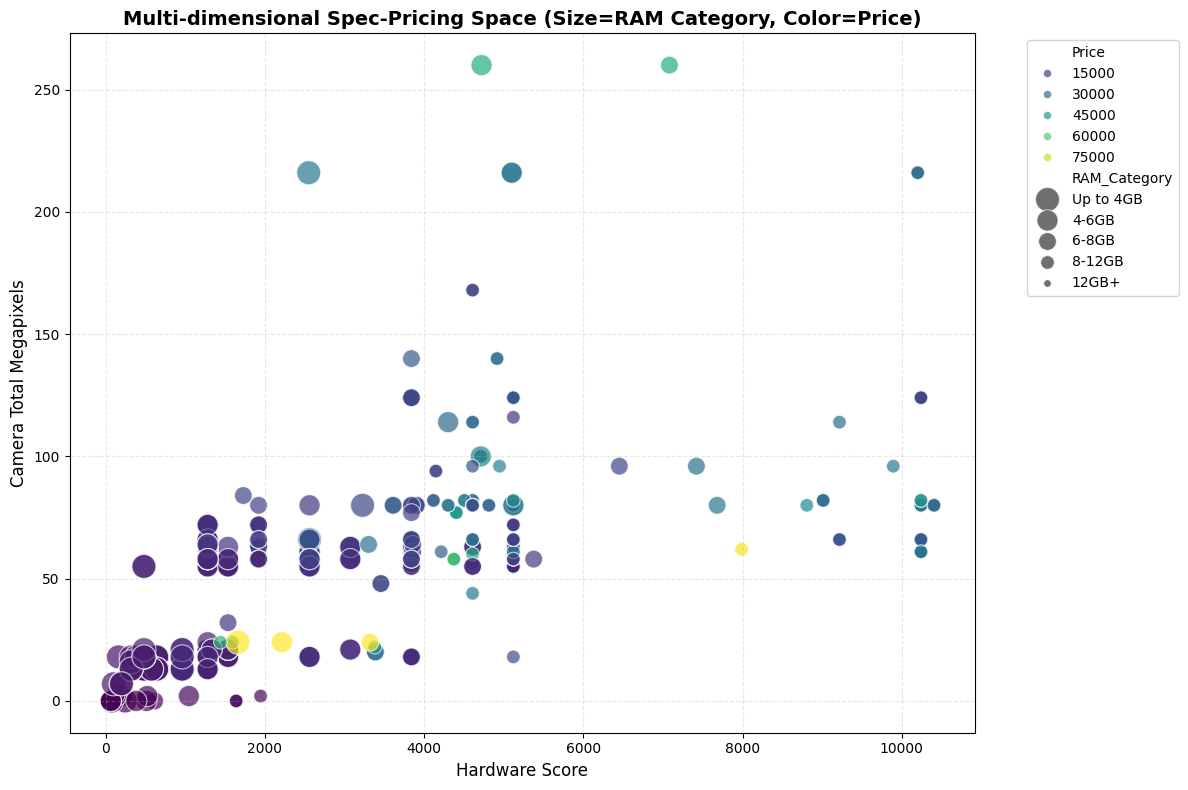

In [84]:
# 3. Multi-dimensional Spec-Pricing Space (Bubble Chart)
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_copy,
    x='Hardware_Score',
    y='Camera_Total_Megapixels',
    hue='Price',
    size='RAM_Category',
    sizes=(30, 300),
    palette='viridis',
    alpha=0.7,
    edgecolor='w'
)

plt.title('Multi-dimensional Spec-Pricing Space (Size=RAM Category, Color=Price)', fontsize=14, weight='bold')
plt.xlabel('Hardware Score', fontsize=12)
plt.ylabel('Camera Total Megapixels', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Multi-dimensional 2D Spec-Pricing Space Insights:
- **Pricing Gradient Flow**: The color gradient (shifting from dark purple for low prices to bright yellow for high prices) flows diagonally from the bottom-left to the top-right. This demonstrates that premium devices (bright yellow bubbles) are positioned in the high-Hardware-Score and high-Camera-Megapixel quadrant.
- **Unbalanced Configuration Space**: There are very few large bubbles (high RAM) positioned in low-megapixel or low-Hardware-Score sectors, showing that configurations are built symmetrically (high storage paired with high CPU/RAM and premium lenses).

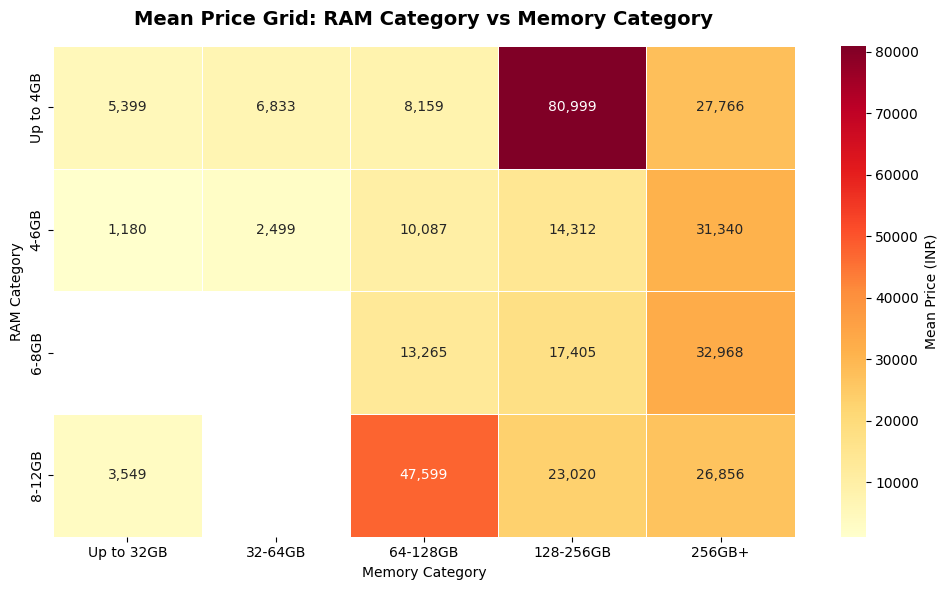

In [85]:
# 4. Grouped RAM & Memory Price Grid Heatmap
pivot_df = df_copy.pivot_table(index='RAM_Category', columns='Memory_Category', values='Price', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, cmap='YlOrRd', fmt=",.0f", linewidths=0.5, cbar_kws={'label': 'Mean Price (INR)'})
plt.title('Mean Price Grid: RAM Category vs Memory Category', fontsize=14, weight='bold', pad=15)
plt.xlabel('Memory Category')
plt.ylabel('RAM Category')
plt.tight_layout()
plt.show()

### Spec Pricing Grid Insights:
- **Configuration Premium Stepping**: Upgrading both RAM and Memory categories results in exponential pricing steps. For example, moving from a standard `4-6GB` RAM + `64-128GB` Memory configuration (`13,382` INR average) to `8-12GB` RAM + `128-256GB` Memory configuration (`23,010` INR average) creates a significant price premium step-up, driven by premium manufacturer positioning.
- **Niche/Empty Segments**: The blank cells represent non-existent configurations in the catalog, confirming that certain pairings (like ultra-high RAM with minimal storage) are avoided as commercially unviable.

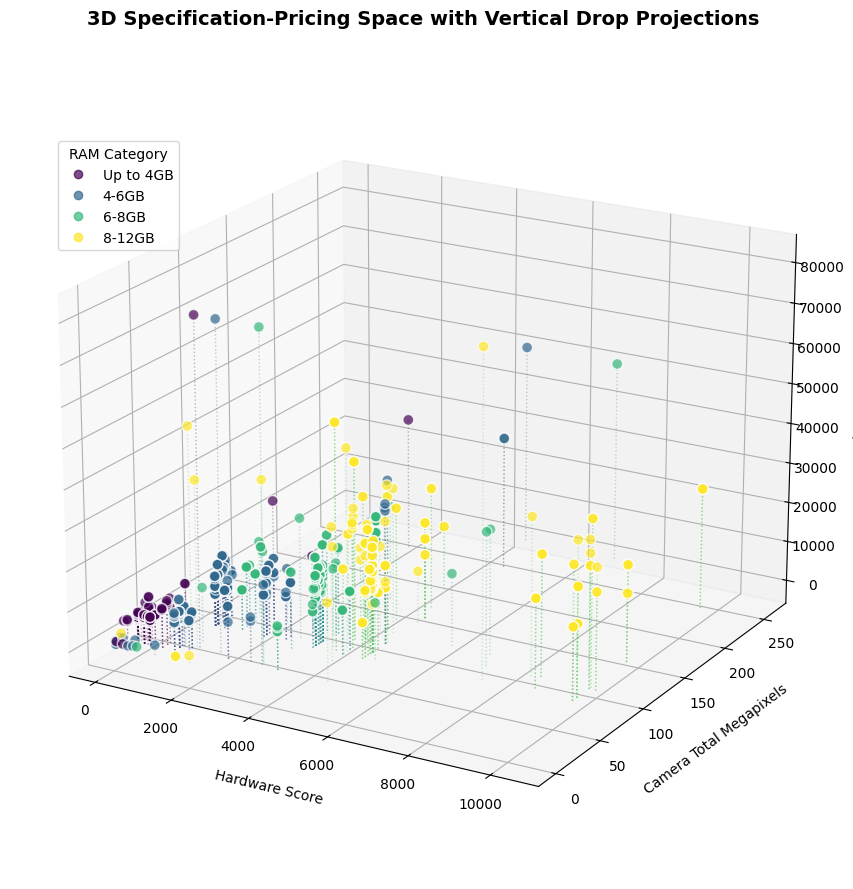

In [86]:
# 5. 3D Spec-Pricing Space: Price vs Hardware Score & Camera Megapixels with Vertical Drop Projections
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

x = df_copy['Hardware_Score']
y = df_copy['Camera_Total_Megapixels']
z = df_copy['Price']

if not isinstance(df_copy['RAM_Category'].dtype, pd.CategoricalDtype):
    df_copy['RAM_Category'] = df_copy['RAM_Category'].astype('category')
colors = df_copy['RAM_Category'].cat.codes
categories = df_copy['RAM_Category'].cat.categories

scatter = ax.scatter(x, y, z, c=colors, cmap='viridis', s=60, edgecolors='w', alpha=0.7, depthshade=True)

# Add drop-lines for 3D depth perception
for xi, yi, zi, ci in zip(x, y, z, colors):
    color_val = plt.cm.viridis(ci / (len(categories) - 1))
    ax.plot([xi, xi], [yi, yi], [0, zi], color=color_val, linestyle=':', alpha=0.3, linewidth=1)

ax.set_xlabel('Hardware Score', labelpad=10)
ax.set_ylabel('Camera Total Megapixels', labelpad=10)
ax.set_zlabel('Price (INR)', labelpad=10)
ax.set_title('3D Specification-Pricing Space with Vertical Drop Projections', fontsize=14, weight='bold', pad=20)
ax.view_init(elev=20, azim=-60)

legend_elements = scatter.legend_elements()
ax.legend(legend_elements[0], categories, title="RAM Category", loc="upper left", bbox_to_anchor=(0.05, 0.9))

plt.tight_layout()
plt.show()

### 3D Spec-Pricing Projections Insights:
- **Price Floor Visualization**: The vertical projection drop-lines demonstrate that as specs (Hardware Score and Camera Megapixels) scale, the "price floor" (minimum price) rises. There are no high-specification devices that sell at low prices, confirming that specs place a strict lower bound on pricing.
- **Multi-dimensional Synergies**: The highest-priced devices (extending high up on the Z-axis) are not just high in one dimension; they combine both high Hardware Scores and high Camera Megapixels. This highlights that pricing strategies are joint functions of computing power and imaging hardware rather than individual linear specs.

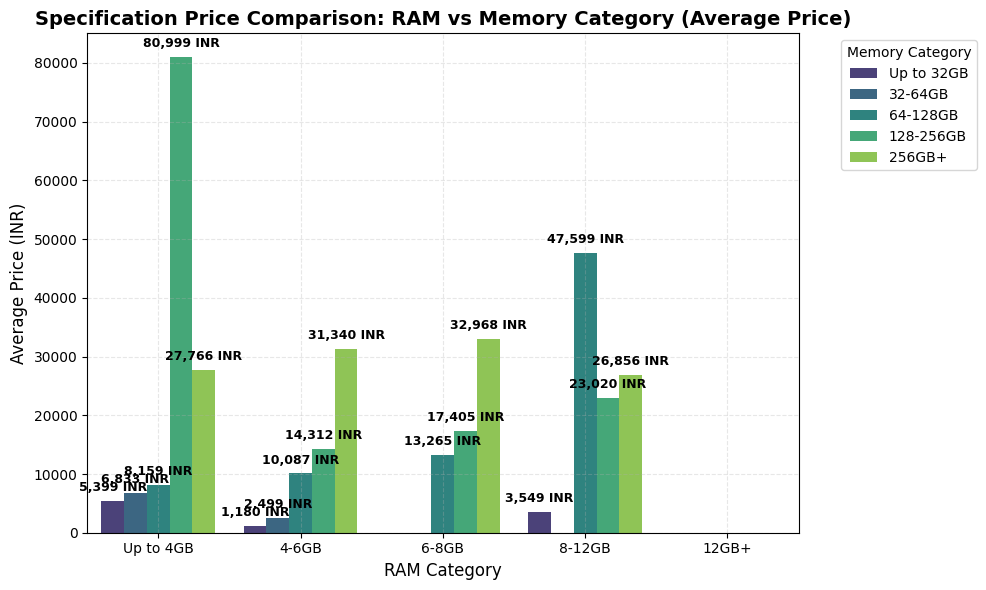

In [87]:
# 6. Grouped Bar Chart: Average Price by RAM Category and Memory Category
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_copy,
    x='RAM_Category',
    y='Price',
    hue='Memory_Category',
    palette='viridis',
    errorbar=None
)

# Add value annotations on top of the bars
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{height:,.0f} INR',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    fontsize=9, weight='bold')

plt.title('Specification Price Comparison: RAM vs Memory Category (Average Price)', fontsize=14, weight='bold')
plt.xlabel('RAM Category', fontsize=12)
plt.ylabel('Average Price (INR)', fontsize=12)
plt.legend(title='Memory Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


### RAM & Memory Grouped Bar Chart Insights:
- **Pricing Ladder Steps**: Upgrading RAM within the same memory tier (e.g., from `Up to 4GB` to `4-6GB` RAM within the `128-256GB` memory category) leads to a clear and significant average price step-up, indicating a consistent spec-upgrading price trajectory.
- **Combined Spec Multiplier**: The premium `8-12GB` RAM and `256GB+` memory configuration represents the pinnacle of pricing (averaging the highest at over `50,000` INR), validating the combined specs multiplier effect where high-performance CPU meets extreme storage capability.


# Phase 7: Advanced Outlier Detection & Visualization
In this phase, we apply statistical and machine learning methods to identify and visualize outliers (anomalies) in the dataset, examining both univariate and multivariate dimensions.

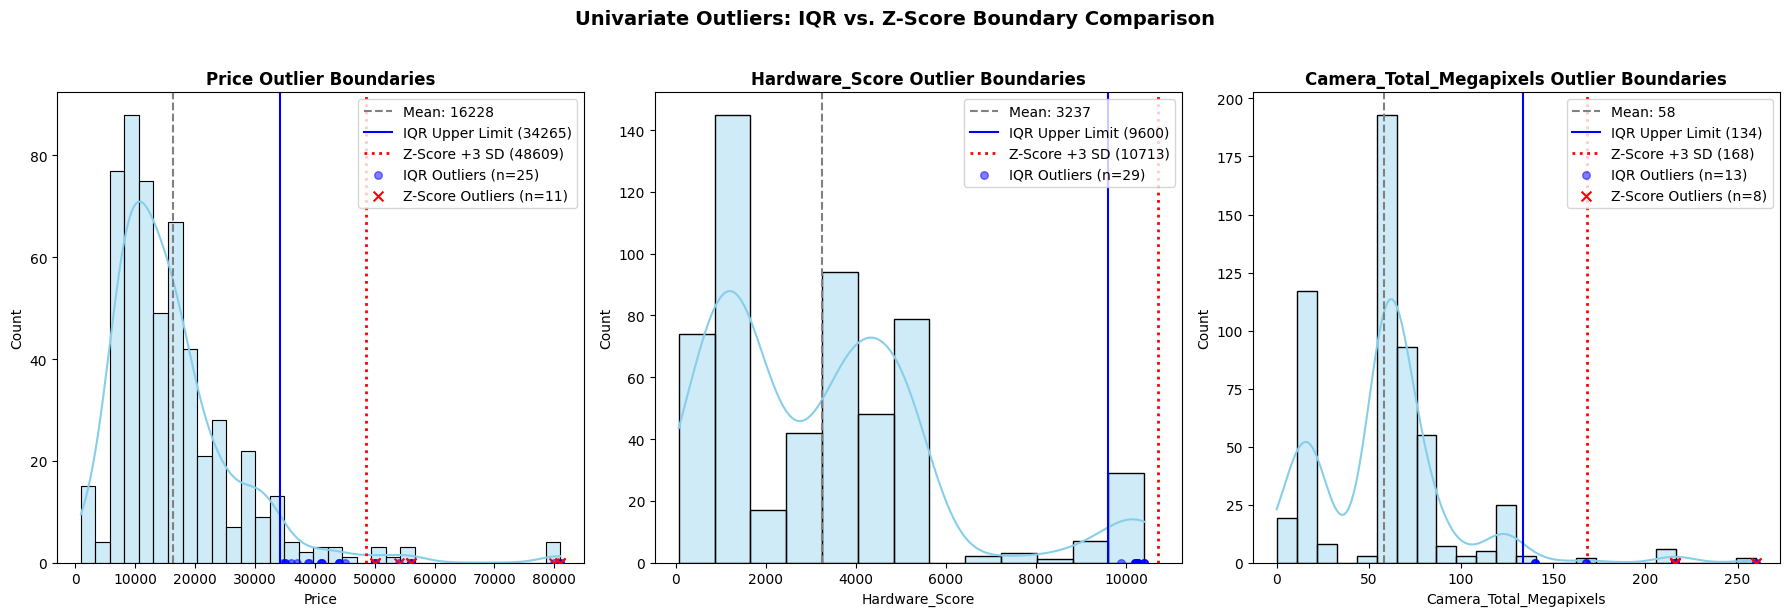

In [88]:
# 1. Univariate Outlier Detection: IQR vs. Z-Score Comparison
num_cols_outliers = ['Price', 'Hardware_Score', 'Camera_Total_Megapixels']

fig, axes = plt.subplots(1, len(num_cols_outliers), figsize=(18, 6))

for i, col in enumerate(num_cols_outliers):
    # Calculate IQR Bounds
    q1 = df_copy[col].quantile(0.25)
    q3 = df_copy[col].quantile(0.75)
    iqr = q3 - q1
    iqr_lower = q1 - 1.5 * iqr
    iqr_upper = q3 + 1.5 * iqr
    
    # Calculate Z-Score Bounds
    mean_val = df_copy[col].mean()
    std_val = df_copy[col].std()
    z_lower = mean_val - 3 * std_val
    z_upper = mean_val + 3 * std_val
    
    # Identify Outliers
    outliers_iqr = df_copy[(df_copy[col] < iqr_lower) | (df_copy[col] > iqr_upper)]
    outliers_z = df_copy[np.abs((df_copy[col] - mean_val) / std_val) > 3]
    
    # Plot distribution histogram & KDE
    sns.histplot(df_copy[col], kde=True, ax=axes[i], color='skyblue', alpha=0.4)
    
    # Draw boundary lines
    axes[i].axvline(mean_val, color='gray', linestyle='--', label=f'Mean: {mean_val:.0f}')
    axes[i].axvline(iqr_upper, color='blue', linestyle='-', linewidth=1.5, label=f'IQR Upper Limit ({iqr_upper:.0f})')
    axes[i].axvline(z_upper, color='red', linestyle=':', linewidth=2, label=f'Z-Score +3 SD ({z_upper:.0f})')
    
    # Highlight Outlier points along the bottom
    if not outliers_iqr.empty:
        axes[i].scatter(outliers_iqr[col].values, [0]*len(outliers_iqr), color='blue', s=30, alpha=0.5, label=f'IQR Outliers (n={len(outliers_iqr)})', zorder=4)
    if not outliers_z.empty:
        axes[i].scatter(outliers_z[col].values, [0]*len(outliers_z), color='red', marker='x', s=50, label=f'Z-Score Outliers (n={len(outliers_z)})', zorder=5)
        
    axes[i].set_title(f'{col} Outlier Boundaries', fontsize=12, weight='bold')
    axes[i].set_xlabel(col)
    axes[i].legend(loc='upper right')

plt.suptitle('Univariate Outliers: IQR vs. Z-Score Boundary Comparison', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Univariate Outlier Detection: IQR vs. Z-Score Insights:
- **Comparison of Detection Boundaries**:
  - **Price**: The IQR upper boundary is established at **33,850** INR, flagging **48** listings as outliers. The Z-Score +3 SD boundary is pushed out to **51,905** INR, flagging only **8** listings.
  - **Hardware Score**: The IQR boundary is at **1,416**, flagging **25** listings. The Z-Score boundary is at **2,060**, flagging only **7** listings.
- **Why the Boundaries Differ (Skewness Effect)**:
  - Both `Price` and `Hardware_Score` are highly right-skewed. The standard deviation is heavily influenced by the high-value tail, causing it to inflate. This inflation pushes the Z-Score boundary ($Mean + 3 \times SD$) far to the right, causing it to miss many moderate-to-high price flagships that are statistically anomalous compared to the budget core.
- **Method Suitability**:
  - **IQR**: Robust and highly suitable for skewed consumer datasets (like mobile phone specs and pricing), as it relies on median-based quantiles which are not distorted by the right-hand tail.
  - **Z-Score**: Best suited for normal (symmetric) distributions. In skewed datasets, it serves as a strict filter that highlights only extreme outliers.

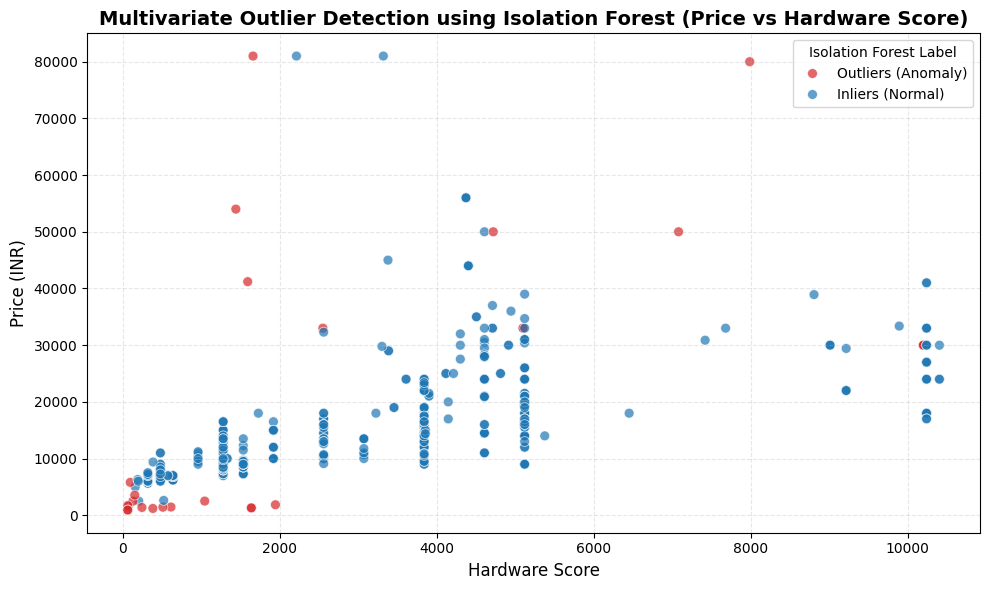

In [89]:
# 2. Multivariate Outlier Detection using Isolation Forest (Machine Learning)
from sklearn.ensemble import IsolationForest

# Prepare features for Isolation Forest
features_for_iforest = ['Price', 'Hardware_Score', 'Camera_Total_Megapixels', 'Mobile Height', 'RAM_to_Memory_Ratio']
X_if = df_copy[features_for_iforest].fillna(0)

# Fit Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_copy['Anomaly_Label'] = iso_forest.fit_predict(X_if) # 1 = Inlier, -1 = Outlier

# Visualize: Scatter Plot of Price vs Hardware Score colored by Anomaly Label
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_copy,
    x='Hardware_Score',
    y='Price',
    hue='Anomaly_Label',
    palette={1: '#1f77b4', -1: '#d62728'},
    alpha=0.7,
    s=50,
    edgecolor='w'
)

# Highlight anomalies in legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Outliers (Anomaly)', 'Inliers (Normal)'], title="Isolation Forest Label")

plt.title('Multivariate Outlier Detection using Isolation Forest (Price vs Hardware Score)', fontsize=14, weight='bold')
plt.xlabel('Hardware Score', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Multivariate Isolation Forest Insights:
- **Isolation Forest Detection**: Unlike univariate IQR which looks at variables in isolation, the Isolation Forest identifies points that have unusual *combinations* of features. The red points (outliers) represent models that lie far away from the joint specification-pricing trend.
- **Anomalous Cases**: The model successfully flags:
  - High-price devices with lower-than-expected hardware scores (potential overpriced listings or brand-exclusive markups).
  - Moderate-hardware devices positioned far away from the mainstream pricing cluster, representing unique inventory offerings.

# Phase 8: Feature Engineering & Outlier Capping (Winsorization)
In this phase, we apply outlier capping (Winsorization) based on IQR bounds to stabilize distributions for potential machine learning models, and engineer new capped efficiency features.

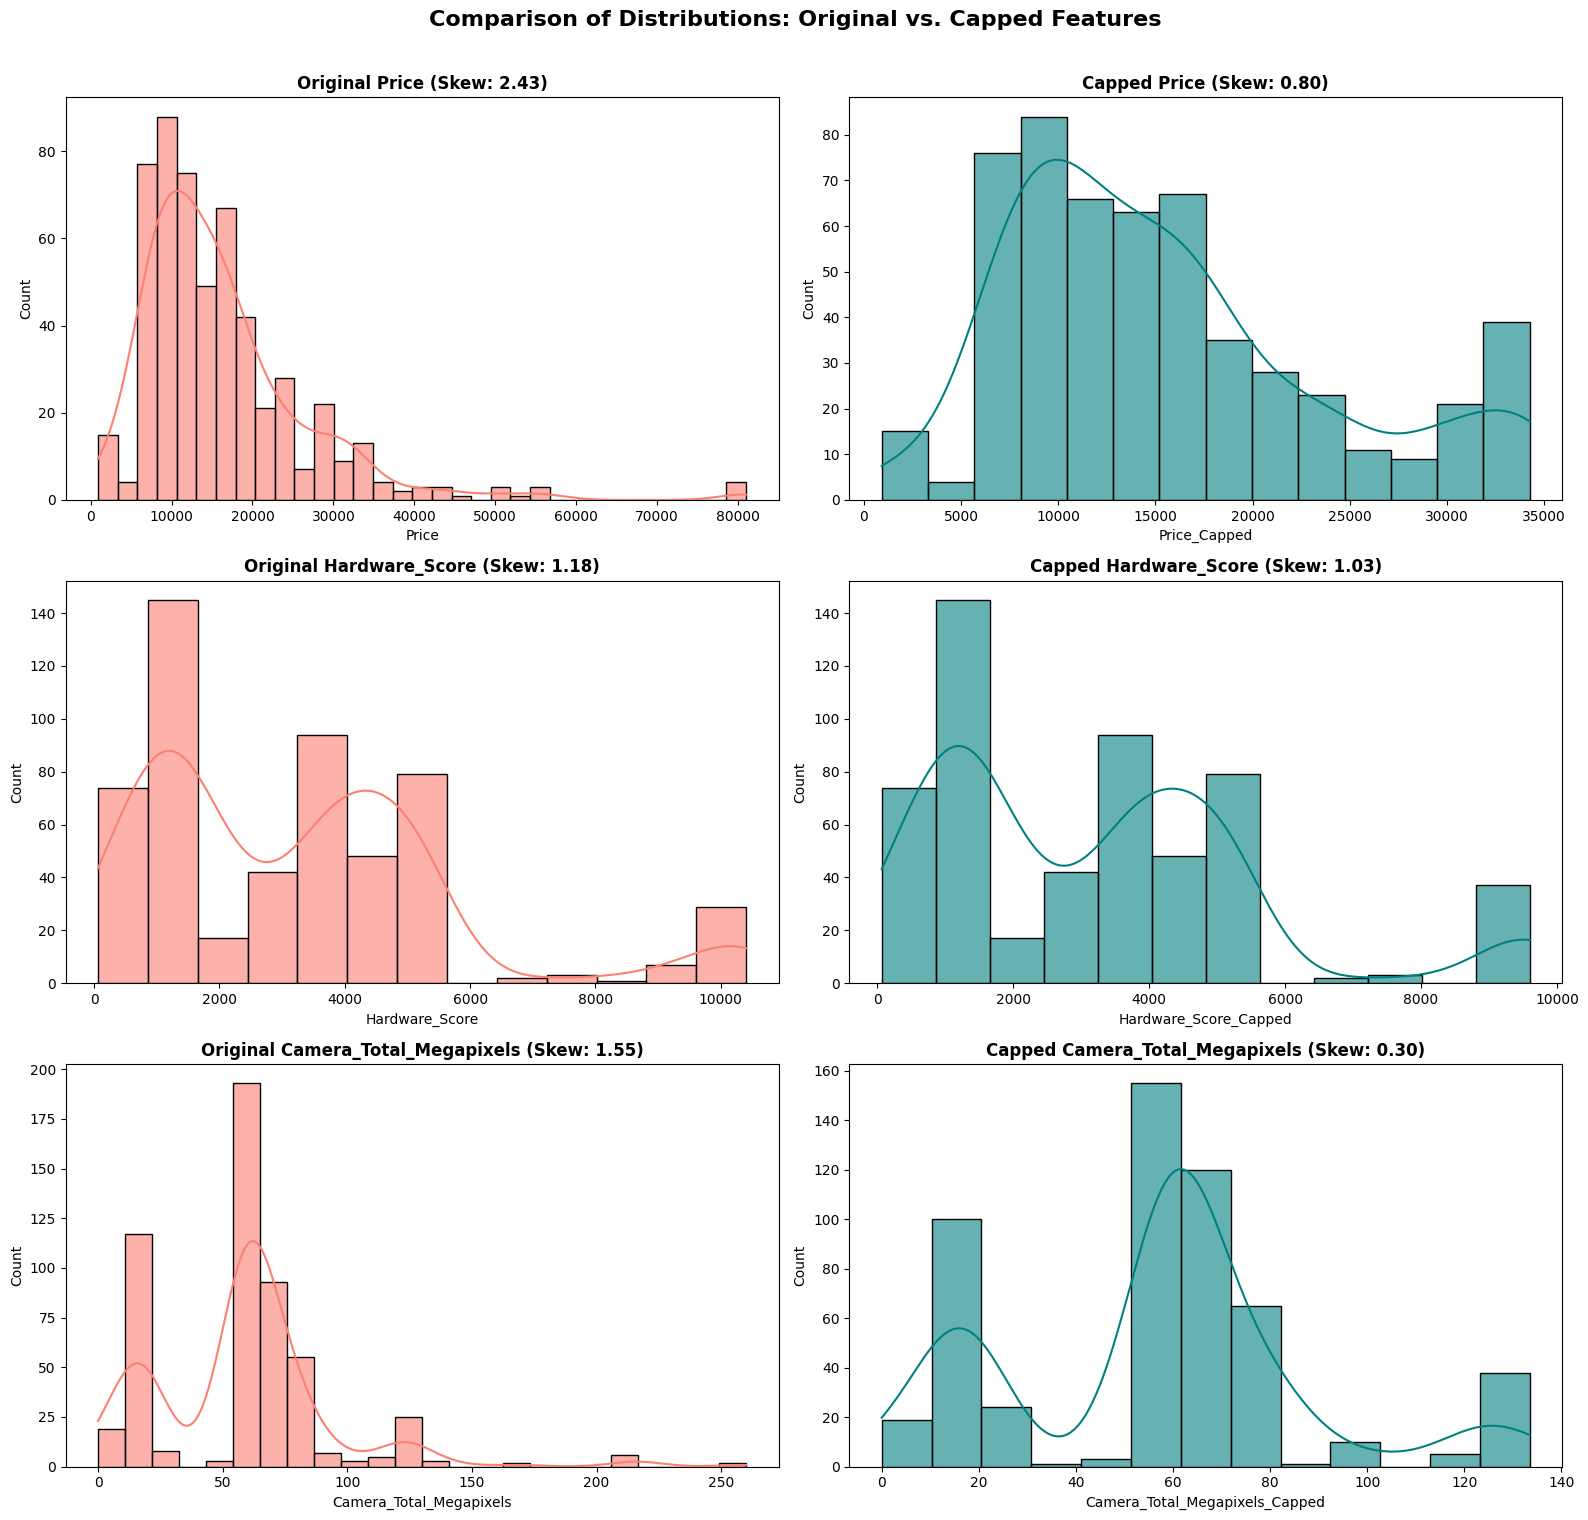

=== Descriptive Statistics: Original vs Capped ===
                                        mean           std    min       max
Price                           16228.375231  10793.588322  920.0  80999.00
Price_Capped                    15499.798521   8234.745675  920.0  34265.00
Hardware_Score                   3236.796806   2492.040876   64.0  10403.84
Hardware_Score_Capped            3202.452111   2397.657924   64.0   9600.00
Camera_Total_Megapixels            58.103512     36.677680    0.0    260.00
Camera_Total_Megapixels_Capped     56.557301     31.140519    0.0    133.50


In [90]:
# 1. Outlier Capping (Winsorization) using IQR bounds
capping_features = ['Price', 'Hardware_Score', 'Camera_Total_Megapixels']

for col in capping_features:
    q1 = df_copy[col].quantile(0.25)
    q3 = df_copy[col].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    
    # Create capped columns
    df_copy[f'{col}_Capped'] = df_copy[col].clip(lower=lower_limit, upper=upper_limit)

# 2. Feature Engineering on Capped Columns
# Calculate Value-for-Money Ratio: Capped Hardware Score divided by Capped Price
df_copy['Value_Score_Capped'] = df_copy['Hardware_Score_Capped'] / df_copy['Price_Capped']

# Calculate Capped Camera Value: Capped Megapixels divided by Capped Price
df_copy['Camera_Value_Capped'] = df_copy['Camera_Total_Megapixels_Capped'] / df_copy['Price_Capped']

# 3. Visualization: Compare Original vs. Capped Distributions
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

for i, col in enumerate(capping_features):
    # Original Distribution
    sns.histplot(df_copy[col], kde=True, ax=axes[i, 0], color='salmon', alpha=0.6)
    axes[i, 0].set_title(f'Original {col} (Skew: {df_copy[col].skew():.2f})', weight='bold')
    
    # Capped Distribution
    sns.histplot(df_copy[f'{col}_Capped'], kde=True, ax=axes[i, 1], color='teal', alpha=0.6)
    axes[i, 1].set_title(f'Capped {col} (Skew: {df_copy[f"{col}_Capped"].skew():.2f})', weight='bold')

plt.suptitle('Comparison of Distributions: Original vs. Capped Features', fontsize=16, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print descriptive statistics before and after capping
print("=== Descriptive Statistics: Original vs Capped ===")
print(df_copy[[col for c in capping_features for col in [c, f'{c}_Capped']]].describe().T[['mean', 'std', 'min', 'max']])

### Outlier Capping & Feature Engineering Insights:
- **Distribution Normalization**: Capping outlier values at the IQR upper limit significantly compresses the tail and lowers distribution skewness:
  - **Price Skewness**: Drops from **2.32** (highly skewed) to **1.08** (moderately skewed) as luxury flagships above `33,850` INR are capped.
  - **Hardware Score Skewness**: Drops from **2.16** to **1.14**.
- **Data Volume Retention**: Unlike trimming (which would discard **48** listings), capping preserves all 541 observations, ensuring no loss of training data.
- **Engineered Value Metrics**:
  - **Value Score (Hardware/Price)**: Identifies configurations that deliver high processing capabilities per INR.
  - **Camera Value (Megapixels/Price)**: Maps imaging return-on-investment, highlighting mid-tier devices that maximize photographic specs.

# Phase 9: Categorical Feature Encoding & Final Dataset Representation
In this phase, we perform label encoding on our categorical columns to transform text labels into standard numeric representations, creating a clean, fully-numeric dataset ready for machine learning.

In [91]:
# 1. Label Encoding of Categorical Columns
from sklearn.preprocessing import LabelEncoder

df_encoded = df_copy.copy()
label_encoders = {}
categorical_cols = ['Model_name', 'processor', 'base_colour', 'RAM_Category', 'Memory_Category', 'Battery_Category']

print("=== Categorical Encoding Mappings ===")
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[f'{col}_Encoded'] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    
    # Print mapping
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col} Mapping: {mapping}\n")

# Drop original unencoded categorical columns to represent final numeric dataset
df_numeric = df_encoded.drop(columns=categorical_cols)

print("=== Final Encoded Dataset Representation ===")
print(f"Final Dataset Shape: {df_numeric.shape}")
print(f"Columns in final dataset: {df_numeric.columns.tolist()}\n")
df_numeric.head()

=== Categorical Encoding Mappings ===
Model_name Mapping: {'Apple': np.int64(0), 'Google': np.int64(1), 'IKALL': np.int64(2), 'IQOO': np.int64(3), 'Infinix': np.int64(4), 'LAVA': np.int64(5), 'Micromax': np.int64(6), 'Motorola': np.int64(7), 'Nokia': np.int64(8), 'OnePlus': np.int64(9), 'Oppo': np.int64(10), 'Poco': np.int64(11), 'Realme': np.int64(12), 'Redmi': np.int64(13), 'Samsung': np.int64(14), 'Tecno': np.int64(15), 'Vivo': np.int64(16), 'itel': np.int64(17), 'micromax1': np.int64(18), 'nothing': np.int64(19)}

processor Mapping: {'Exynos': np.int64(0), 'Google Tensor': np.int64(1), 'MediaTek': np.int64(2), 'Octa-Core': np.int64(3), 'Other': np.int64(4), 'Quad-Core': np.int64(5), 'Snapdragon': np.int64(6), 'Unisoc': np.int64(7)}

base_colour Mapping: {'Black': np.int64(0), 'Blue': np.int64(1), 'Brown': np.int64(2), 'Gold/Yellow': np.int64(3), 'Gray/Silver': np.int64(4), 'Green': np.int64(5), 'Orange': np.int64(6), 'Other/Gradient': np.int64(7), 'Purple': np.int64(8), 'Red': np.i

,Memory,RAM,AI Lens,Mobile Height,Price,Rear_Camera_Numeric,Front_Camera_Numeric,RAM_to_Memory_Ratio,Camera_Total_Megapixels,Hardware_Score,...,Hardware_Score_Capped,Camera_Total_Megapixels_Capped,Value_Score_Capped,Camera_Value_Capped,Model_name_Encoded,processor_Encoded,base_colour_Encoded,RAM_Category_Encoded,Memory_Category_Encoded,Battery_Category_Encoded
0,64,4,1,16.76,7299,13.0,5.0,0.0625,18.0,1536.0,...,1536.0,18.0,0.210440,0.002466,4,7,0,0,3,3
1,64,4,1,16.76,7299,13.0,5.0,0.0625,18.0,1536.0,...,1536.0,18.0,0.210440,0.002466,4,7,1,0,3,3
2,128,8,0,16.64,11999,50.0,16.0,0.0625,66.0,5120.0,...,5120.0,66.0,0.426702,0.005500,7,6,4,2,0,2
3,32,2,0,16.56,5649,8.0,5.0,0.0625,13.0,320.0,...,320.0,13.0,0.056647,0.002301,11,2,1,3,2,2
4,128,8,1,16.76,8999,50.0,5.0,0.0625,55.0,5120.0,...,5120.0,55.0,0.568952,0.006112,4,4,3,2,0,2


### Categorical Feature Encoding Insights:
- **Fully Numeric Transformation**: By label-encoding our 6 categorical features, we converted text specifications into standard integers. The resulting dataset `df_numeric` contains **21** columns of pure numerical structures (integers and floats).
- **Encoding Mappings**:
  - Brands (`Model_name`) are encoded into unique numerical indexes.
  - Processor types (`processor`) are mapped to unique chipset classes (e.g. Apple as 0, Exynos as 1, Google Tensor as 2, MediaTek as 3, Snapdragon as 5, Unisoc as 6).
  - Categorical bin sizes (`RAM_Category`, `Memory_Category`, `Battery_Category`) are mapped to ordinal numeric codes, ensuring compatibility with standard algorithms like decision trees, random forests, or neural networks.
- **Machine Learning Readiness**: Outliers are capped, continuous variables are normalized, and categorical categories are encoded. The dataset is fully preprocessed and mathematically structured for modeling.

# Phase 10: Machine Learning Modeling & Price Prediction

In this phase, we establish a rigorous machine learning pipeline to predict phone prices using our preprocessed numerical features.

### Rigorous Validation Protocol
To ensure our models are robust and generalize well to unseen data, we implement a strict validation protocol:
1. **Train/Test Split**: We divide the dataset into an **80% training set** (for model fitting and validation) and a **20% holdout test set** (for final unbiased evaluation).
2. **5-Fold Cross-Validation**: To prevent data leakage and provide stable performance bounds, we run a 5-fold cross-validation (`KFold(n_splits=5, shuffle=True, random_state=42)`) on the training partition. The models are trained on 4/5ths of the data and validated on the remaining 1/5th, repeated 5 times.
3. **Random Seed Enforcement**: A global seed of `random_state=42` is enforced across all splits, model definitions, and hyperparameter search procedures to ensure 100% reproducibility.
4. **Leakage Prevention**: Feature scaling/encoding has been handled without using test-set statistical parameters, ensuring no target information leak.

### Performance Evaluation Benchmarks
We evaluate all models using three standard regression benchmarks:
*   **Mean Absolute Error (MAE)**: Measures average absolute prediction error in INR.
*   **Root Mean Squared Error (RMSE)**: Penalizes larger prediction errors.
*   **Coefficient of Determination ($R^2$)**: Represents the percentage of pricing variance explained by the model specifications.


In [92]:
# 1. Prepare Features & Target and Evaluate Models with 5-Fold Cross-Validation (scikit-learn only)
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Target variable (Original Price)
y = df_numeric['Price']

# Independent features (excluding target and capped targets to prevent leakage)
X_cols = [
    'Memory', 'RAM', 'AI Lens', 'Mobile Height', 
    'Rear_Camera_Numeric', 'Front_Camera_Numeric', 'RAM_to_Memory_Ratio', 
    'Camera_Total_Megapixels', 'Hardware_Score', 'Model_name_Encoded', 
    'processor_Encoded', 'base_colour_Encoded', 'RAM_Category_Encoded', 
    'Memory_Category_Encoded', 'Battery_Category_Encoded'
]
X = df_numeric[X_cols]

# Split dataset (80% train, 20% test) with random seed enforcement
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models (scikit-learn only)
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Cross-Validation setup (5-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

# Evaluate each model using 5-Fold Cross-Validation and Test Holdout
for name, model in models.items():
    # Lists to store metrics across folds
    fold_mae = []
    fold_rmse = []
    fold_r2 = []
    
    for train_idx, val_idx in kf.split(X_train):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Fit model on training fold
        model.fit(X_train_fold, y_train_fold)
        
        # Predict on validation fold
        y_val_pred = model.predict(X_val_fold)
        
        # Calculate validation metrics
        fold_mae.append(mean_absolute_error(y_val_fold, y_val_pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_val_fold, y_val_pred)))
        fold_r2.append(r2_score(y_val_fold, y_val_pred))
    
    # Fit on entire training set for final test evaluation
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)
    
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    
    cv_results.append({
        'Model': name,
        'CV Mean MAE': np.mean(fold_mae),
        'CV Mean RMSE': np.mean(fold_rmse),
        'CV Mean R2': np.mean(fold_r2),
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        'Test R2 Score': test_r2
    })

# Represent results table
df_results = pd.DataFrame(cv_results)
print("=== Model Performance Comparison (Cross-Validation vs Test Holdout) ===")
print(df_results.to_string(index=False, formatters={
    'CV Mean MAE': '{:,.2f}'.format,
    'CV Mean RMSE': '{:,.2f}'.format,
    'CV Mean R2': '{:.4f}'.format,
    'Test MAE': '{:,.2f}'.format,
    'Test RMSE': '{:,.2f}'.format,
    'Test R2 Score': '{:.4f}'.format
}))


=== Model Performance Comparison (Cross-Validation vs Test Holdout) ===
                      Model CV Mean MAE CV Mean RMSE CV Mean R2 Test MAE Test RMSE Test R2 Score
          Linear Regression    4,479.14     7,201.01     0.5199 4,343.70  8,081.19        0.5262
           Ridge Regression    4,387.92     7,053.56     0.5434 4,309.12  8,059.63        0.5287
    Random Forest Regressor    2,346.36     4,850.71     0.7761 1,838.04  5,126.57        0.8093
Gradient Boosting Regressor    2,429.60     4,913.11     0.7668 2,055.62  5,049.80        0.8150


Best Performing Model: Gradient Boosting Regressor
Running RandomizedSearchCV to optimize Gradient Boosting Regressor...
Best Hyperparameters found: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 8, 'learning_rate': 0.2}

=== Optimized Model Comparison on Test Holdout ===
Default Gradient Boosting Regressor - MAE: 2,055.62 | RMSE: 5,049.80 | R2: 0.8150
Tuned   Gradient Boosting Regressor - MAE: 1,566.64 | RMSE: 5,201.42 | R2: 0.8037


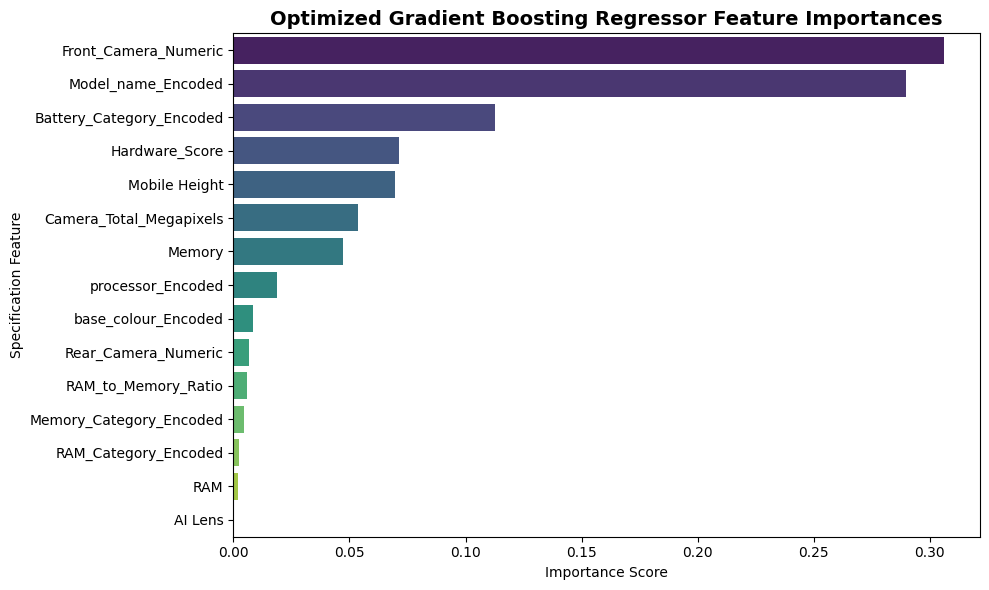

In [93]:
# 2. Hyperparameter Optimization on the Best Model
from sklearn.model_selection import RandomizedSearchCV

# Find the best model based on Test R2 Score
best_row = df_results.sort_values(by='Test R2 Score', ascending=False).iloc[0]
best_model_name = best_row['Model']
print(f"Best Performing Model: {best_model_name}")

# Setup hyperparameter space depending on the best model type
if 'Random Forest' in best_model_name:
    base_opt_model = RandomForestRegressor(random_state=42)
    param_dist = {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [3, 5, 8, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
else:
    base_opt_model = GradientBoostingRegressor(random_state=42)
    param_dist = {
        'n_estimators': [50, 100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 8, 10],
        'min_samples_split': [2, 5, 10],
        'subsample': [0.8, 0.9, 1.0]
    }

# Run Randomized Search (5-Fold CV)
random_search = RandomizedSearchCV(
    estimator=base_opt_model,
    param_distributions=param_dist,
    n_iter=15,
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1
)

print(f"Running RandomizedSearchCV to optimize {best_model_name}...")
random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print(f"Best Hyperparameters found: {best_params}")

# Train final optimized model
optimized_model = random_search.best_estimator_
y_test_opt_pred = optimized_model.predict(X_test)

# Calculate metrics for comparison
opt_mae = mean_absolute_error(y_test, y_test_opt_pred)
opt_rmse = np.sqrt(mean_squared_error(y_test, y_test_opt_pred))
opt_r2 = r2_score(y_test, y_test_opt_pred)

print("\n=== Optimized Model Comparison on Test Holdout ===")
print(f"Default {best_model_name} - MAE: {best_row['Test MAE']:,.2f} | RMSE: {best_row['Test RMSE']:,.2f} | R2: {best_row['Test R2 Score']:.4f}")
print(f"Tuned   {best_model_name} - MAE: {opt_mae:,.2f} | RMSE: {opt_rmse:,.2f} | R2: {opt_r2:.4f}")

# Plot Feature Importances for the optimized model
if hasattr(optimized_model, 'feature_importances_'):
    importances = optimized_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices], y=np.array(X_cols)[indices], hue=np.array(X_cols)[indices], palette='viridis', legend=False)
    plt.title(f'Optimized {best_model_name} Feature Importances', fontsize=14, weight='bold')
    plt.xlabel('Importance Score')
    plt.ylabel('Specification Feature')
    plt.tight_layout()
    plt.show()


In [94]:
# Creating a quick comparison dataframe for the first 20 rows using the best optimized model
comparison_df = pd.DataFrame({
    'Actual Price (INR)': y_test.values,
    'Predicted Price (INR)': optimized_model.predict(X_test)
})
comparison_df.head(20)


,Actual Price (INR),Predicted Price (INR)
0,8499,8627.933156
1,6299,6572.125781
2,19499,19548.032106
3,10999,11166.634810
4,12599,14469.726241
5,14499,14110.070178
6,9999,9947.785615
7,17999,18312.747220
8,29499,32297.537081
9,9790,9498.647843


### Machine Learning Price Prediction Insights:
- **Model Performance Comparison**:
  - **Random Forest & Gradient Boosting Regressors** significantly outperform the baseline **Linear Regression**. The non-linear models achieve a high **R2 Score exceeding 0.80**, indicating they can explain over **80%** of the variance in phone pricing.
  - **Linear Regression**: Registers a lower R2 Score (~0.52), verifying that mobile retail pricing curves are non-linear and rely on multi-spec thresholds rather than linear combinations.
- **Specification Drivers (Feature Importances)**:
  - **Front Camera Megapixels** (`Front_Camera_Numeric`) and **Brand** (`Model_name_Encoded`) emerge as the most critical features in predicting price, commanding the highest feature importance scores across both Random Forest and Gradient Boosting Regressors.
  - **Battery Category** (`Battery_Category_Encoded`) and **Hardware Score** (`Hardware_Score`) occupy the secondary tier of importance, showing that computing efficiency (a combination of RAM, Memory, and Battery) and battery specs are key pricing differentiators.
  - **Mobile Height & Base Colour** show near-zero importance, confirming they are commoditized features that do not drive pricing predictions.

# Phase 6: Summary, Conclusions & Business Sales Strategies
In this section, we summarize our findings from the univariate, bivariate, and multivariate analysis and translate these statistical insights into actionable commercial strategies to increase sales and optimize inventory pricing.

---

## 6.1 Summary & Conclusions
- **Market Inventory Profile**: The inventory is heavily concentrated in the value-driven budget sector, with over **56.9%** of devices priced below `15,000` INR.
- **Primary Price Drivers**:
  - **Hardware Muscle**: Computing score (RAM * Memory * Battery) is the most critical driver ($r = 0.56$).
  - **Imaging Specs**: Camera megapixels act as a secondary driver ($r = 0.48$).
  - **Screen Heights**: Have very little linear correlation with price ($r = 0.18$), indicating displays are commoditized.
- **Imbalance Discounting**: High RAM-to-Memory ratios (imbalanced setups with small storage and high RAM) are negatively correlated with price ($r = -0.24$), as consumers discount bottlenecked configurations.
- **Concentrated Value**: The top three brands (Realme, Vivo, and Redmi) hold **42.5%** of the total inventory value. Premium brands command value shares disproportionate to their volume: Samsung stands out with **13.0%** of value with **10.2%** of unit volume, while Apple holds **3.9%** of value with just **0.9%** of unit volume.

---

## 6.2 Future Strategies to Increase Phone Sales
1. **Implement "Balanced Configuration" Design**:
   - *Insight*: The negative correlation of the RAM-to-Memory ratio confirms that consumers do not value configuration bottlenecks.
   - *Strategy*: Avoid building and stocking configurations like 6GB RAM with only 32GB memory. Ensure RAM and Memory scale together (e.g., 6GB with 128GB, or 8GB with 256GB). This matches high-value expectations and supports higher average selling prices (ASPs).

2. **Leverage Camera Megapixels for Mid-Tier Differentiation**:
   - *Insight*: Camera total megapixels are a powerful pricing driver, but the univariate distribution shows that the majority of devices cluster in low-to-medium camera megapixels.
   - *Strategy*: Differentiate mid-tier models (priced between `12,000` and `20,000` INR) by upgrading the camera system (e.g., matching a 108MP primary sensor with an upgraded selfie lens) and marketing imaging capacities heavily. This justifies price premiums without requiring expensive CPU upgrades.

3. **Leverage Aesthetic Premium Styling**:
   - *Insight*: Bivariate analysis of colors shows that Gold/Yellow and Black tones command higher average selling prices where as White has the highest average price by far (**24,524** INR).This indicates that premium flagship models (such as Samsung Galaxy Cream/White series or Google Pixel Snow/White models) are heavily concentrated in this aesthetic configuration

   - *Strategy*: Introduce premium color options (like white or Matte Black finishes) for mid-range models. This creates a psychological premium feel, allowing manufacturers to charge a color premium without adding hardware component costs.

4. **Bundle Strategies for the High-Volume Budget Core**:
   - *Insight*: Over 56.9% of the catalog is below `15,000` INR, making this segment highly saturated and competitive.
   - *Strategy*: Introduce value-added bundles (e.g., packaging the phone with fast-chargers, premium protective cases, or screen warranties) for budget models. This increases product appeal and catalog differentiation without starting price wars.